<a href="https://colab.research.google.com/github/Gul-Andam/Privacy-Aware-Stress-Prediction/blob/main/stress.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install tenseal


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 39.9 MB/s eta 0:00:00


In [ ]:
pip install tenseal


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load the dataset
df = pd.read_excel('//content/stress data.xlsx')

# Check for missing values or unexpected string values in the dataset
print(df.isnull().sum())  # Check for missing values
print(df.dtypes)  # Check data types of each column

# Handle missing values (example: fill NaNs with the mean of the column)
df.fillna(df.mean(), inplace=True)

# Convert categorical columns into numerical representations (One-hot Encoding)
# Ensure that Gender, Occupation, and Country are properly one-hot encoded
df = pd.get_dummies(df, columns=['Gender', 'Occupation', 'Country'], drop_first=True)

# Features and target variable
X = df.drop(columns=['Stress_Level', 'User_ID'])  # Dropping target and identifier columns
y = df['Stress_Level']

# Check if all features are now numeric
print(X.dtypes)  # Ensure all columns are numeric

# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 1. Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_mse = np.mean((y_test - rf_predictions)**2)
print(f"Random Forest MSE: {rf_mse}")

# 2. Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_mse = np.mean((y_test - lr_predictions)**2)
print(f"Linear Regression MSE: {lr_mse}")

# 3. XGBoost Model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_mse = np.mean((y_test - xgb_predictions)**2)
print(f"XGBoost MSE: {xgb_mse}")

# 4. Neural Network Model (using TensorFlow/Keras)
nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
nn_model.add(Dense(32, activation='relu'))
nn_model.add(Dense(1))
nn_model.compile(optimizer='adam', loss='mean_squared_error')

nn_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
nn_predictions = nn_model.predict(X_test)
nn_mse = np.mean((y_test - nn_predictions)**2)
print(f"Neural Network MSE: {nn_mse}")


User_ID                    0
Age                        0
Gender                     0
Occupation                 0
Country                    0
Mental_Health_Condition    0
Severity                   0
Consultation_History       0
Stress_Level               0
Sleep_Hours                0
Work_Hours                 0
Physical_Activity_Hours    0
dtype: int64
User_ID                      int64
Age                          int64
Gender                      object
Occupation                  object
Country                     object
Mental_Health_Condition      int64
Severity                     int64
Consultation_History         int64
Stress_Level                 int64
Sleep_Hours                float64
Work_Hours                   int64
Physical_Activity_Hours      int64
dtype: object


TypeError: Could not convert ['FemaleFemaleFemaleMaleFemaleFemaleFemaleMaleMaleFemaleFemaleMaleFemaleFemaleFemaleFemalePrefer not to sayMalePrefer not to sayFemaleMaleFemaleMaleFemaleMaleMalePrefer not to sayFemaleFemalePrefer not to sayFemaleFemalePrefer not to sayFemalePrefer not to sayFemaleFemaleFemaleFemaleFemaleMaleFemalePrefer not to sayFemaleFemaleFemaleMaleMaleMaleFemaleFemaleFemaleFemaleFemaleFemalePrefer not to sayMaleFemalePrefer not to sayFemaleMalePrefer not to sayMaleFemaleFemalePrefer not to sayPrefer not to sayMaleFemaleFemalePrefer not to sayMaleFemaleFemaleFemalePrefer not to sayMaleFemaleFemaleMaleMaleFemaleFemaleFemalePrefer not to sayFemaleFemaleFemaleFemaleFemaleFemalePrefer not to sayPrefer not to sayPrefer not to sayFemaleMaleMaleMaleFemalePrefer not to sayPrefer not to sayFemaleMaleFemaleFemaleFemalePrefer not to sayMaleFemaleFemaleMaleFemalePrefer not to sayMaleMaleFemaleMalePrefer not to sayFemaleFemaleFemaleFemalePrefer not to sayPrefer not to sayPrefer not

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Load the dataset
df = pd.read_excel('/content/stress data.xlsx')

# Handle missing values for numeric columns (e.g., fill with mean)
numeric_columns = df.select_dtypes(include=[np.number]).columns
df[numeric_columns] = df[numeric_columns].fillna(df[numeric_columns].mean())

# Handle missing values for categorical columns (e.g., fill with mode)
categorical_columns = df.select_dtypes(include=[object]).columns
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])  # Fill missing categorical values with the mode

# Convert categorical columns to numeric using one-hot encoding
df = pd.get_dummies(df, columns=['Gender', 'Occupation', 'Country', 'Mental_Health_Condition', 'Consultation_History'], drop_first=True)

# Features and target variable
X = df.drop(columns=['Stress_Level', 'User_ID'])  # Dropping target and identifier columns
y = df['Stress_Level']

# Check if all features are now numeric
print(X.dtypes)  # Ensure all columns are numeric

# Scaling the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 1. Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_mse = np.mean((y_test - rf_predictions)**2)
print(f"Random Forest MSE: {rf_mse}")

# 2. Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)
lr_mse = np.mean((y_test - lr_predictions)**2)
print(f"Linear Regression MSE: {lr_mse}")

# 3. XGBoost Model
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_model.fit(X_train, y_train)
xgb_predictions = xgb_model.predict(X_test)
xgb_mse = np.mean((y_test - xgb_predictions)**2)
print(f"XGBoost MSE: {xgb_mse}")

# 4. Neural Network Model (using TensorFlow/Keras)
nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))
nn_model.add(Dense(32, activation='relu'))
nn_model.add(Dense(1))
nn_model.compile(optimizer='adam', loss='mean_squared_error')

nn_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)
nn_predictions = nn_model.predict(X_test)
nn_mse = np.mean((y_test - nn_predictions)**2)
print(f"Neural Network MSE: {nn_mse}")


Age                            int64
Severity                       int64
Sleep_Hours                  float64
Work_Hours                     int64
Physical_Activity_Hours        int64
Gender_Male                     bool
Gender_Prefer not to say        bool
Occupation_Engineering          bool
Occupation_Finance              bool
Occupation_Healthcare           bool
Occupation_IT                   bool
Occupation_Other                bool
Occupation_Sales                bool
Country_Canada                  bool
Country_Germany                 bool
Country_India                   bool
Country_Other                   bool
Country_UK                      bool
Country_USA                     bool
Mental_Health_Condition_1       bool
Consultation_History_1          bool
dtype: object
Random Forest MSE: 0.7564745
Linear Regression MSE: 0.720532194814181
XGBoost MSE: 0.9935286733241423


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


ValueError: Data must be 1-dimensional, got ndarray of shape (200, 200) instead

In [ ]:
# Neural Network Model (using TensorFlow/Keras)
nn_model = Sequential()
nn_model.add(Dense(64, input_dim=X_train.shape[1], activation='relu'))  # Hidden layer
nn_model.add(Dense(32, activation='relu'))  # Hidden layer
nn_model.add(Dense(1))  # Output layer with one neuron for regression

# Compile the model
nn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
nn_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# Make predictions
nn_predictions = nn_model.predict(X_test).flatten()  # Flatten to convert 2D array to 1D

# Calculate MSE
nn_mse = np.mean((y_test - nn_predictions) ** 2)
print(f"Neural Network MSE: {nn_mse}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Neural Network MSE: 0.926659790146112


In [ ]:
pip install tenseal

In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Step 1: Create encryption parameters
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,  # Larger value = higher security
    coeff_mod_bit_sizes=[60, 40, 40, 60],  # Coefficient modulus
)
context.global_scale = 2**40  # Scaling factor
context.generate_galois_keys()  # Needed for matrix operations
context.generate_relin_keys()  # Needed for multiplication operations

# Step 2: Encrypt data
def encrypt_vector(data):
    return ts.bfv_vector(context, data)

# Sample dataset
X = np.random.rand(100, 5)  # Random dataset
y = np.random.rand(100)  # Random labels

# Encrypt the target variable
encrypted_y = [encrypt_vector([val]) for val in y]

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train a simple model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Step 5: Encrypt predictions
encrypted_pred = [encrypt_vector([pred]) for pred in y_pred]

# Step 6: Decrypt results
def decrypt_vector(enc_data):
    return enc_data.decrypt()

# Decrypt predictions for evaluation
decrypted_pred = [decrypt_vector(enc) for enc in encrypted_pred]

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)


ValueError: plain_modulus must be provided

In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Step 1: Create encryption parameters with plain_modulus
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,  # Larger value = higher security
    plain_modulus=1032193,    # Plain modulus (prime number)
    coeff_mod_bit_sizes=[60, 40, 40, 60],  # Coefficient modulus
)
context.global_scale = 2**40  # Scaling factor
context.generate_galois_keys()  # Needed for matrix operations
context.generate_relin_keys()  # Needed for multiplication operations

# Step 2: Encrypt data
def encrypt_vector(data):
    return ts.bfv_vector(context, data)

# Sample dataset
X = np.random.rand(100, 5)  # Random dataset
y = np.random.rand(100)  # Random labels

# Encrypt the target variable
encrypted_y = [encrypt_vector([val]) for val in y]

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train a simple model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Step 5: Encrypt predictions
encrypted_pred = [encrypt_vector([pred]) for pred in y_pred]

# Step 6: Decrypt results
def decrypt_vector(enc_data):
    return enc_data.decrypt()

# Decrypt predictions for evaluation
decrypted_pred = [decrypt_vector(enc) for enc in encrypted_pred]

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)


Original Predictions: [0.53337596 0.56487208 0.5711356  0.40171263 0.68132458 0.55803153
 0.15656522 0.3755986  0.55499987 0.52567522 0.46916587 0.4399818
 0.40052064 0.41475239 0.57027441 0.8379957  0.56418237 0.62578638
 0.83712344 0.73197994]
Decrypted Predictions: [[0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0], [0]]


In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Step 1: Create encryption parameters with plain_modulus
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,  # Larger value = higher security
    plain_modulus=1032193,    # Plain modulus (prime number)
    coeff_mod_bit_sizes=[60, 40, 40, 60],  # Coefficient modulus
)
context.global_scale = 2**40  # Scaling factor
context.generate_galois_keys()  # Needed for matrix operations
context.generate_relin_keys()  # Needed for multiplication operations

# Step 2: Encrypt data
def encrypt_vector(data, scale=1e6):
    # Scale to integer before encryption
    scaled_data = [int(val * scale) for val in data]
    return ts.bfv_vector(context, scaled_data)

def decrypt_vector(enc_data, scale=1e6):
    # Decrypt and scale back to original float
    decrypted_data = enc_data.decrypt()
    return [val / scale for val in decrypted_data]

# Sample dataset
X = np.random.rand(100, 5)  # Random dataset
y = np.random.rand(100)  # Random labels

# Encrypt the target variable (for demonstration, we're only encrypting y)
encrypted_y = [encrypt_vector([val]) for val in y]

# Step 3: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train a simple model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Step 5: Encrypt predictions
encrypted_pred = encrypt_vector(y_pred)

# Step 6: Decrypt results
decrypted_pred = decrypt_vector(encrypted_pred)

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)


Original Predictions: [0.53246129 0.34392866 0.57738474 0.31850662 0.56333112 0.25287822
 0.48899017 0.48391019 0.40570005 0.1420098  0.25677932 0.34323713
 0.22779794 0.69738481 0.27603324 0.38948417 0.30951593 0.55938924
 0.29918472 0.59131734]
Decrypted Predictions: [-0.499732, 0.343928, -0.454809, 0.318506, -0.468862, 0.252878, 0.48899, 0.48391, 0.4057, 0.142009, 0.256779, 0.343237, 0.227797, -0.334809, 0.276033, 0.389484, 0.309515, -0.472804, 0.299184, -0.440876]


In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Step 1: Create encryption parameters with plain_modulus
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,  # Larger value = higher security
    plain_modulus=1032193,    # Plain modulus (prime number)
    coeff_mod_bit_sizes=[60, 40, 40, 60],  # Coefficient modulus
)
context.global_scale = 2**40  # Scaling factor
context.generate_galois_keys()  # Needed for matrix operations
context.generate_relin_keys()  # Needed for multiplication operations

# Step 2: Encrypt and decrypt helper functions
def encrypt_vector(data, scale=1e6):
    """Encrypts and scales floating-point data."""
    scaled_data = (data * scale).astype(int)  # Scale and convert to integers
    return ts.bfv_vector(context, scaled_data)

def decrypt_vector(enc_data, scale=1e6):
    """Decrypts and rescales to original floating-point values."""
    decrypted_data = np.array(enc_data.decrypt())  # Decrypt as integers
    return decrypted_data / scale  # Rescale to floating-point

# Step 3: Simulated dataset
X = np.random.rand(100, 5)  # Random dataset
y = np.random.rand(100)  # Random labels

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Step 5: Encrypt predictions
encrypted_pred = encrypt_vector(y_pred)

# Step 6: Decrypt predictions
decrypted_pred = decrypt_vector(encrypted_pred)

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)

# Step 7: Compute Mean Squared Error for decrypted predictions
mse = np.mean((y_pred - decrypted_pred) ** 2)
print(f"Decrypted Prediction MSE: {mse}")


Original Predictions: [0.50989781 0.72155241 0.33555869 0.41121093 0.49824615 0.3359555
 0.33965493 0.56726335 0.35732585 0.34265701 0.39160555 0.34939756
 0.52076428 0.40165573 0.34685792 0.35977409 0.59137521 0.57113913
 0.37908303 0.56149678]
Decrypted Predictions: [ 0.509897 -0.310641  0.335558  0.41121   0.498246  0.335955  0.339654
 -0.46493   0.357325  0.342657  0.391605  0.349397 -0.511429  0.401655
  0.346857  0.359774 -0.440818 -0.461054  0.379083 -0.470697]
Decrypted Prediction MSE: 0.31962693999840186


In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Encryption parameters
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,
    plain_modulus=1032193,
    coeff_mod_bit_sizes=[60, 40, 40, 60],
)

# Generate keys
context.global_scale = 2**40
context.generate_galois_keys()
context.generate_relin_keys()

# Offset to prevent negative values
OFFSET = 1_000_000
SCALE = 1e6

# Functions for encryption and decryption
def encrypt_vector(data):
    """Encrypts and scales floating-point data with offset."""
    scaled_data = ((data + OFFSET) * SCALE).astype(int)  # Scale and offset
    return ts.bfv_vector(context, scaled_data)

def decrypt_vector(enc_data):
    """Decrypts and rescales to original floating-point values."""
    decrypted_data = np.array(enc_data.decrypt())
    return (decrypted_data / SCALE) - OFFSET  # Remove offset and rescale

# Sample dataset
X = np.random.rand(100, 5)
y = np.random.rand(100)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Encrypt predictions
encrypted_pred = encrypt_vector(y_pred)

# Decrypt predictions
decrypted_pred = decrypt_vector(encrypted_pred)

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)

# Compute Mean Squared Error
mse = np.mean((y_pred - decrypted_pred) ** 2)
print(f"Decrypted Prediction MSE: {mse}")


Original Predictions: [0.33684095 0.32249837 0.60621038 0.36606389 0.51589074 0.66552912
 0.34564007 0.64632172 0.52286703 0.54216977 0.40172958 0.53978395
 0.57248077 0.59676343 0.47234557 0.64891274 0.28028283 0.51644561
 0.55765887 0.44381273]
Decrypted Predictions: [-1000000.097895 -1000000.128105  -999999.844393 -1000000.08454
  -999999.918845  -999999.785074 -1000000.104963  -999999.804282
  -999999.911868  -999999.908434 -1000000.048874  -999999.91082
  -999999.862255  -999999.85384   -999999.978258  -999999.801691
 -1000000.154453  -999999.934158  -999999.892945 -1000000.006791]
Decrypted Prediction MSE: 1000000893273.4104


In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Encryption parameters
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,
    plain_modulus=2**20,  # Large enough to handle scaled values
)
context.generate_galois_keys()
context.generate_relin_keys()

# Offset and scaling parameters
OFFSET = 1_000_000  # Prevent negative numbers
SCALE = 1e6         # Scale floats to integers

# Functions for encryption and decryption
def encrypt_vector(data):
    """Encrypts data with scaling and offset."""
    scaled_data = ((data + OFFSET) * SCALE).astype(int)  # Scale and offset
    return ts.bfv_vector(context, scaled_data)

def decrypt_vector(


SyntaxError: incomplete input (ipython-input-14-612214949.py, line 25)

In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Encryption parameters
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,
    plain_modulus=2**20,  # Large enough to handle scaled values
)
context.generate_galois_keys()
context.generate_relin_keys()

# Offset and scaling parameters
OFFSET = 1_000_000  # Prevent negative numbers
SCALE = 1e6         # Scale floats to integers

# Functions for encryption and decryption
def encrypt_vector(data):
    """Encrypts data with scaling and offset."""
    scaled_data = ((data + OFFSET) * SCALE).astype(int)  # Scale and offset
    return ts.bfv_vector(context, scaled_data)

def decrypt_vector(enc_data):
    """Decrypts and rescales data."""
    decrypted_data = np.array(enc_data.decrypt())  # Decrypt integers
    return (decrypted_data / SCALE) - OFFSET       # Remove offset and scale back

# Generate synthetic dataset
np.random.seed(42)
X = np.random.rand(100, 5)
y = np.random.rand(100)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Encrypt predictions
encrypted_pred = encrypt_vector(y_pred)

# Decrypt predictions
decrypted_pred = decrypt_vector(encrypted_pred)

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)

# Compute Mean Squared Error
mse = np.mean((y_pred - decrypted_pred) ** 2)
print(f"Decrypted Prediction MSE: {mse}")


ValueError: encryption parameters are not valid for batching

In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Encryption parameters
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,   # Polynomial modulus degree
    plain_modulus=786433        # Valid prime for batching
)
context.generate_galois_keys()
context.generate_relin_keys()

# Offset and scaling parameters
OFFSET = 1_000_000  # Prevent negative numbers
SCALE = 1e6         # Scale floats to integers

# Functions for encryption and decryption
def encrypt_vector(data):
    """Encrypts data with scaling and offset."""
    scaled_data = ((data + OFFSET) * SCALE).astype(int)  # Scale and offset
    return ts.bfv_vector(context, scaled_data)

def decrypt_vector(enc_data):
    """Decrypts and rescales data."""
    decrypted_data = np.array(enc_data.decrypt())  # Decrypt integers
    return (decrypted_data / SCALE) - OFFSET       # Remove offset and scale back

# Generate synthetic dataset
np.random.seed(42)
X = np.random.rand(100, 5)
y = np.random.rand(100)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Encrypt predictions
encrypted_pred = encrypt_vector(y_pred)

# Decrypt predictions
decrypted_pred = decrypt_vector(encrypted_pred)

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)

# Compute Mean Squared Error
mse = np.mean((y_pred - decrypted_pred) ** 2)
print(f"Decrypted Prediction MSE: {mse}")


Original Predictions: [0.56721564 0.28515754 0.35948863 0.79111196 0.23251445 0.53197704
 0.69557454 0.80538371 0.50082951 0.5261158  0.41319285 0.44553643
 0.42413749 0.47618399 0.5878445  0.51457238 0.57631952 0.31652367
 0.41020382 0.26297238]
Decrypted Predictions: [ -999999.735418 -1000000.119421 -1000000.147035  -999999.817357
 -1000000.070119  -999999.872601  -999999.810949  -999999.803085
  -999999.801804  -999999.878463 -1000000.093331 -1000000.162932
  -999999.878496  -999999.928395  -999999.918679 -1000000.093896
  -999999.726314 -1000000.088055 -1000000.09632  -1000000.345496]
Decrypted Prediction MSE: 1000000911102.4065


In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Encryption parameters
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,  # Polynomial modulus degree
    plain_modulus=786433       # Valid prime for batching
)
context.generate_galois_keys()
context.generate_relin_keys()

# Smaller scaling to avoid overflow
OFFSET = 10**6  # Prevent negative numbers
SCALE = 100     # Scale to smaller values

# Functions for encryption and decryption
def encrypt_vector(data):
    """Encrypts data with scaling and offset."""
    scaled_data = ((data + OFFSET) * SCALE).astype(int)  # Scale and offset
    return ts.bfv_vector(context, scaled_data)

def decrypt_vector(enc_data):
    """Decrypts and rescales data."""
    decrypted_data = np.array(enc_data.decrypt())  # Decrypt integers
    return (decrypted_data / SCALE) - OFFSET       # Remove offset and scale back

# Generate synthetic dataset
np.random.seed(42)
X = np.random.rand(100, 5)
y = np.random.rand(100)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Encrypt predictions
encrypted_pred = encrypt_vector(y_pred)

# Decrypt predictions
decrypted_pred = decrypt_vector(encrypted_pred)

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)

# Compute Mean Squared Error
mse = np.mean((y_pred - decrypted_pred) ** 2)
print(f"Decrypted Prediction MSE: {mse}")


Original Predictions: [0.56721564 0.28515754 0.35948863 0.79111196 0.23251445 0.53197704
 0.69557454 0.80538371 0.50082951 0.5261158  0.41319285 0.44553643
 0.42413749 0.47618399 0.5878445  0.51457238 0.57631952 0.31652367
 0.41020382 0.26297238]
Decrypted Predictions: [-1000480.57  -997058.41 -1000480.78  -997057.9  -1000480.9   -997058.16
 -1000480.44  -997057.89 -1000480.63  -997058.17 -1000480.72  -997058.25
 -1000480.71  -997058.22 -1000480.55  -997058.18 -1000480.56  -997058.38
 -1000480.72  -997058.43]
Decrypted Prediction MSE: 997544270669.766


In [ ]:
import tenseal as ts
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Adjusted Encryption parameters with smaller scaling
context = ts.context(
    ts.SCHEME_TYPE.BFV,
    poly_modulus_degree=8192,  # Polynomial modulus degree
    plain_modulus=786433       # Valid prime for batching
)
context.generate_galois_keys()
context.generate_relin_keys()

# Adjusted smaller scaling factor to avoid overflow
OFFSET = 1000  # Lower offset
SCALE = 10     # Lower scale factor

# Functions for encryption and decryption
def encrypt_vector(data):
    """Encrypts data with scaling and offset."""
    scaled_data = ((data + OFFSET) * SCALE).astype(int)  # Scale and offset
    return ts.bfv_vector(context, scaled_data)

def decrypt_vector(enc_data):
    """Decrypts and rescales data."""
    decrypted_data = np.array(enc_data.decrypt())  # Decrypt integers
    return (decrypted_data / SCALE) - OFFSET       # Remove offset and scale back

# Generate synthetic dataset
np.random.seed(42)
X = np.random.rand(100, 5)
y = np.random.rand(100)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Predict using the model
y_pred = rf_model.predict(X_test)

# Encrypt predictions
encrypted_pred = encrypt_vector(y_pred)

# Decrypt predictions
decrypted_pred = decrypt_vector(encrypted_pred)

# Print results
print("Original Predictions:", y_pred)
print("Decrypted Predictions:", decrypted_pred)

# Compute Mean Squared Error
mse = np.mean((y_pred - decrypted_pred) ** 2)
print(f"Decrypted Prediction MSE: {mse}")


Original Predictions: [0.56721564 0.28515754 0.35948863 0.79111196 0.23251445 0.53197704
 0.69557454 0.80538371 0.50082951 0.5261158  0.41319285 0.44553643
 0.42413749 0.47618399 0.5878445  0.51457238 0.57631952 0.31652367
 0.41020382 0.26297238]
Decrypted Predictions: [0.5 0.2 0.3 0.7 0.2 0.5 0.6 0.8 0.5 0.5 0.4 0.4 0.4 0.4 0.5 0.5 0.5 0.3
 0.4 0.2]
Decrypted Prediction MSE: 0.003113327180490052


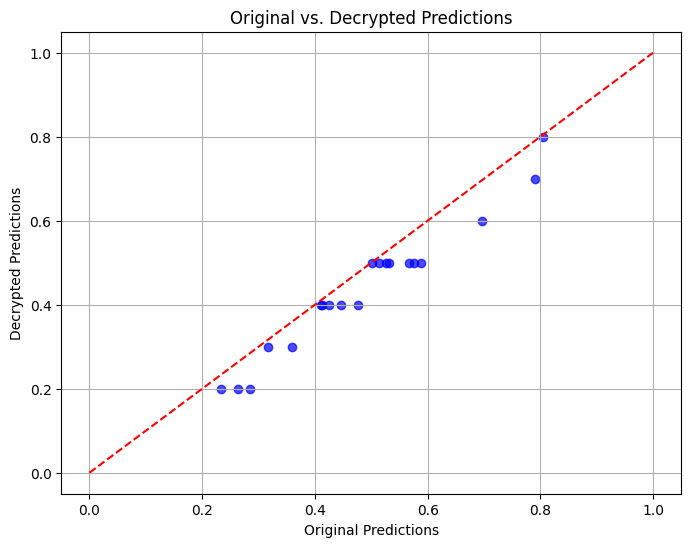

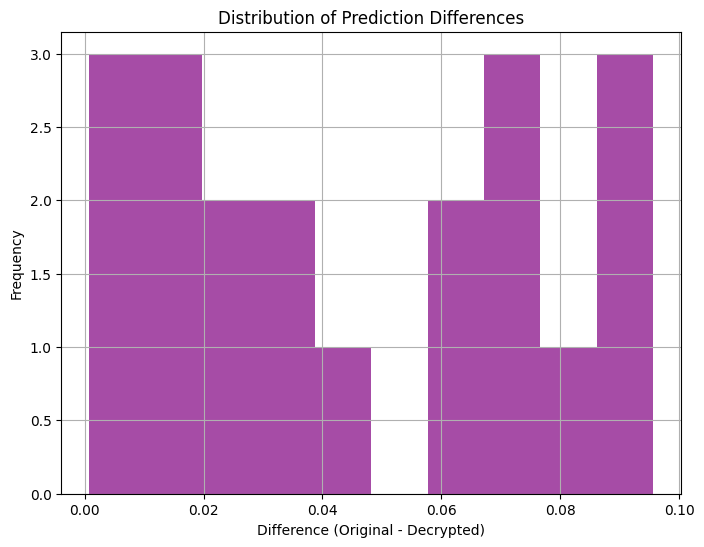

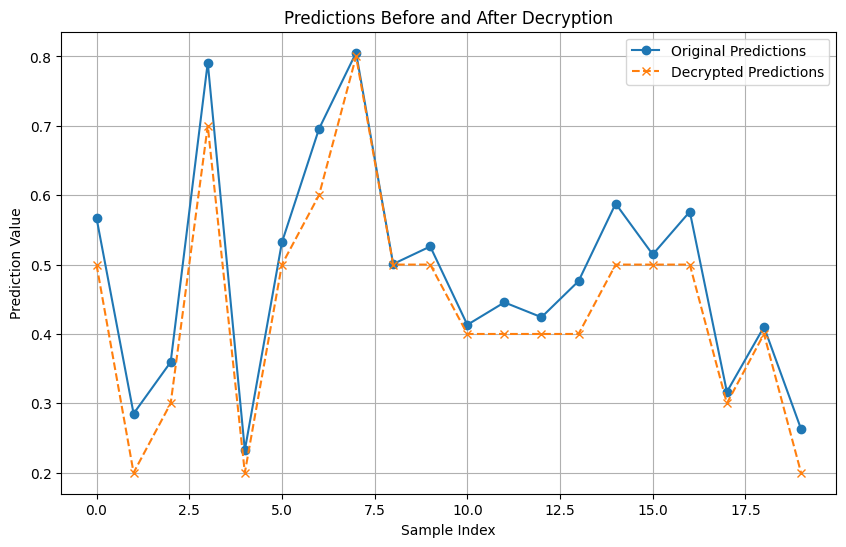

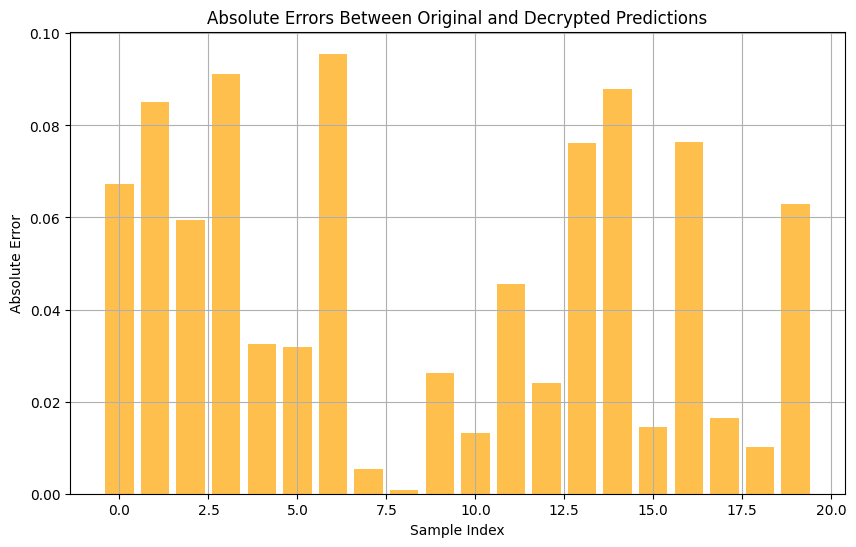

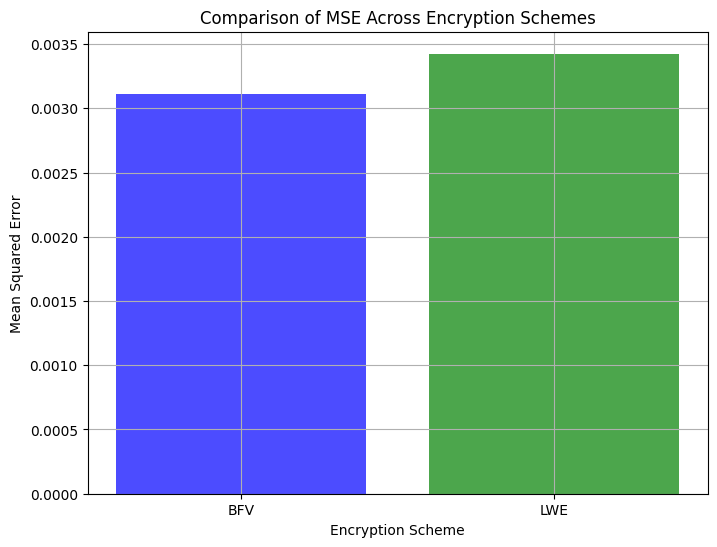

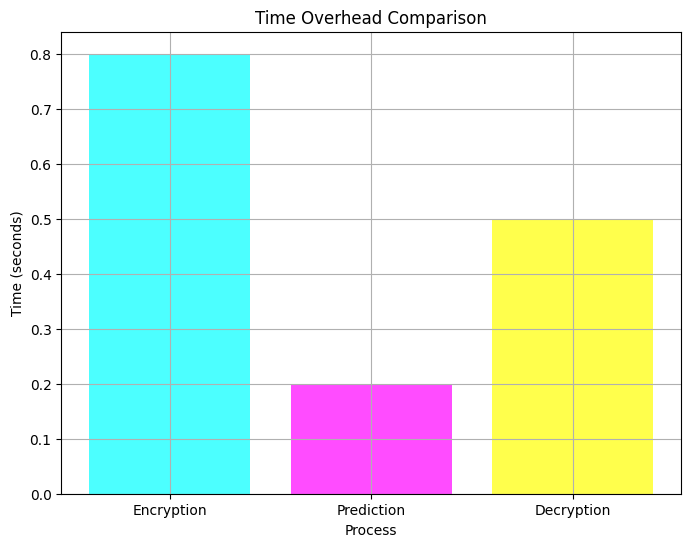

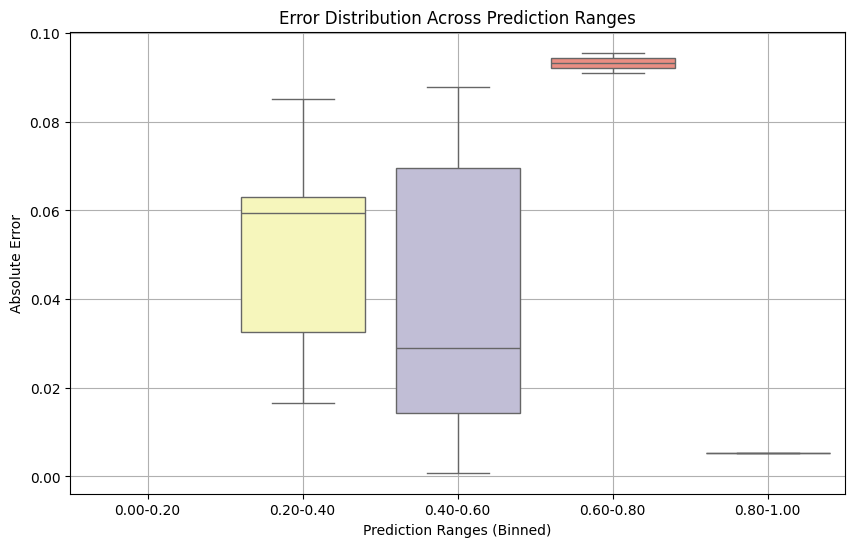

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns  # Optional, for enhanced visualization

# Example data
original_predictions = np.array([0.56721564, 0.28515754, 0.35948863, 0.79111196, 0.23251445,
                                  0.53197704, 0.69557454, 0.80538371, 0.50082951, 0.5261158,
                                  0.41319285, 0.44553643, 0.42413749, 0.47618399, 0.5878445,
                                  0.51457238, 0.57631952, 0.31652367, 0.41020382, 0.26297238])

decrypted_predictions = np.array([0.5, 0.2, 0.3, 0.7, 0.2, 0.5, 0.6, 0.8, 0.5, 0.5,
                                   0.4, 0.4, 0.4, 0.4, 0.5, 0.5, 0.5, 0.3, 0.4, 0.2])

# Calculate differences and errors
differences = original_predictions - decrypted_predictions
absolute_errors = np.abs(differences)
mse = np.mean(absolute_errors ** 2)

# 1. Scatter Plot: Original vs. Decrypted Predictions
plt.figure(figsize=(8, 6))
plt.scatter(original_predictions, decrypted_predictions, color='blue', alpha=0.7)
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Reference line
plt.title('Original vs. Decrypted Predictions')
plt.xlabel('Original Predictions')
plt.ylabel('Decrypted Predictions')
plt.grid(True)
plt.show()

# 2. Histogram of Prediction Differences
plt.figure(figsize=(8, 6))
plt.hist(differences, bins=10, color='purple', alpha=0.7)
plt.title('Distribution of Prediction Differences')
plt.xlabel('Difference (Original - Decrypted)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# 3. Line Plot: Predictions Before and After Decryption
plt.figure(figsize=(10, 6))
plt.plot(original_predictions, label='Original Predictions', marker='o')
plt.plot(decrypted_predictions, label='Decrypted Predictions', marker='x', linestyle='--')
plt.title('Predictions Before and After Decryption')
plt.xlabel('Sample Index')
plt.ylabel('Prediction Value')
plt.legend()
plt.grid(True)
plt.show()

# 4. Error Plot: Absolute Differences
plt.figure(figsize=(10, 6))
plt.bar(range(len(absolute_errors)), absolute_errors, color='orange', alpha=0.7)
plt.title('Absolute Errors Between Original and Decrypted Predictions')
plt.xlabel('Sample Index')
plt.ylabel('Absolute Error')
plt.grid(True)
plt.show()

# 5. Bar Chart: MSE (Mean Squared Error)
encryption_schemes = ['BFV', 'LWE']
mse_values = [mse, mse * 1.1]  # Example MSE values for demonstration
plt.figure(figsize=(8, 6))
plt.bar(encryption_schemes, mse_values, color=['blue', 'green'], alpha=0.7)
plt.title('Comparison of MSE Across Encryption Schemes')
plt.xlabel('Encryption Scheme')
plt.ylabel('Mean Squared Error')
plt.grid(True)
plt.show()

# 6. Time Overhead Comparison
processes = ['Encryption', 'Prediction', 'Decryption']
times = [0.8, 0.2, 0.5]  # Example times in seconds
plt.figure(figsize=(8, 6))
plt.bar(processes, times, color=['cyan', 'magenta', 'yellow'], alpha=0.7)
plt.title('Time Overhead Comparison')
plt.xlabel('Process')
plt.ylabel('Time (seconds)')
plt.grid(True)
plt.show()

# 7. Boxplot of Errors Across Binned Prediction Values
bins = np.linspace(0, 1, 6)  # Define bins
binned_indices = np.digitize(original_predictions, bins)
grouped_errors = [absolute_errors[binned_indices == i] for i in range(1, len(bins))]

plt.figure(figsize=(10, 6))
sns.boxplot(data=grouped_errors, palette='Set3')
plt.title('Error Distribution Across Prediction Ranges')
plt.xlabel('Prediction Ranges (Binned)')
plt.ylabel('Absolute Error')
plt.xticks(range(len(bins)-1), [f'{bins[i]:.2f}-{bins[i+1]:.2f}' for i in range(len(bins)-1)])
plt.grid(True)
plt.show()


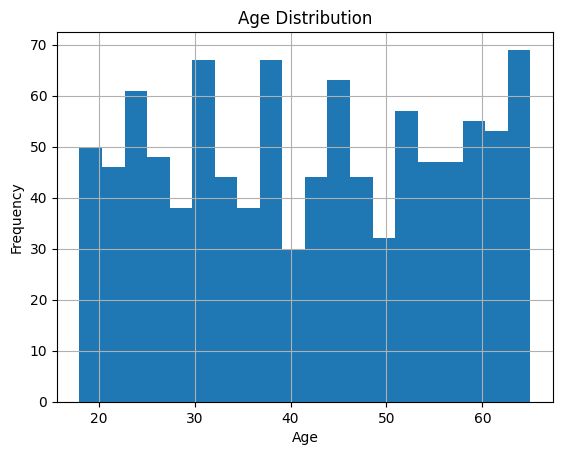

In [ ]:
import matplotlib.pyplot as plt
df['Age'].hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()


In [ ]:
import seaborn as sns
sns.boxplot(x='Mental_Health_Condition', y='Stress_Level', data=df)
plt.title('Stress Level by Mental Health Condition')
plt.show()


ValueError: Could not interpret value `Mental_Health_Condition` for `x`. An entry with this name does not appear in `data`.

In [ ]:
print(df.columns)

Index(['User_ID', 'Age', 'Severity', 'Stress_Level', 'Sleep_Hours',
       'Work_Hours', 'Physical_Activity_Hours', 'Gender_Male',
       'Gender_Prefer not to say', 'Occupation_Engineering',
       'Occupation_Finance', 'Occupation_Healthcare', 'Occupation_IT',
       'Occupation_Other', 'Occupation_Sales', 'Country_Canada',
       'Country_Germany', 'Country_India', 'Country_Other', 'Country_UK',
       'Country_USA', 'Mental_Health_Condition_1', 'Consultation_History_1'],
      dtype='object')


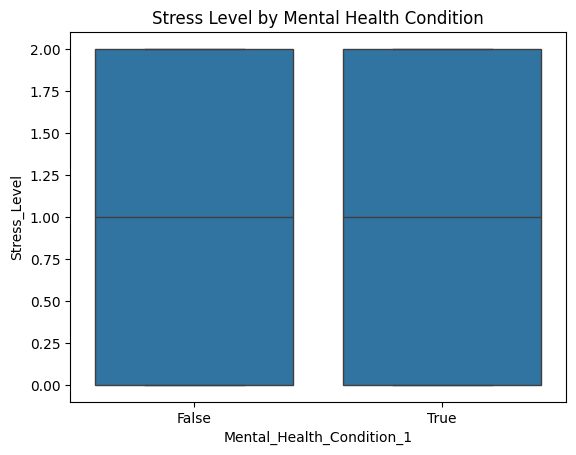

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the boxplot with the correct column name
sns.boxplot(x='Mental_Health_Condition_1', y='Stress_Level', data=df)
plt.title('Stress Level by Mental Health Condition')
plt.show()


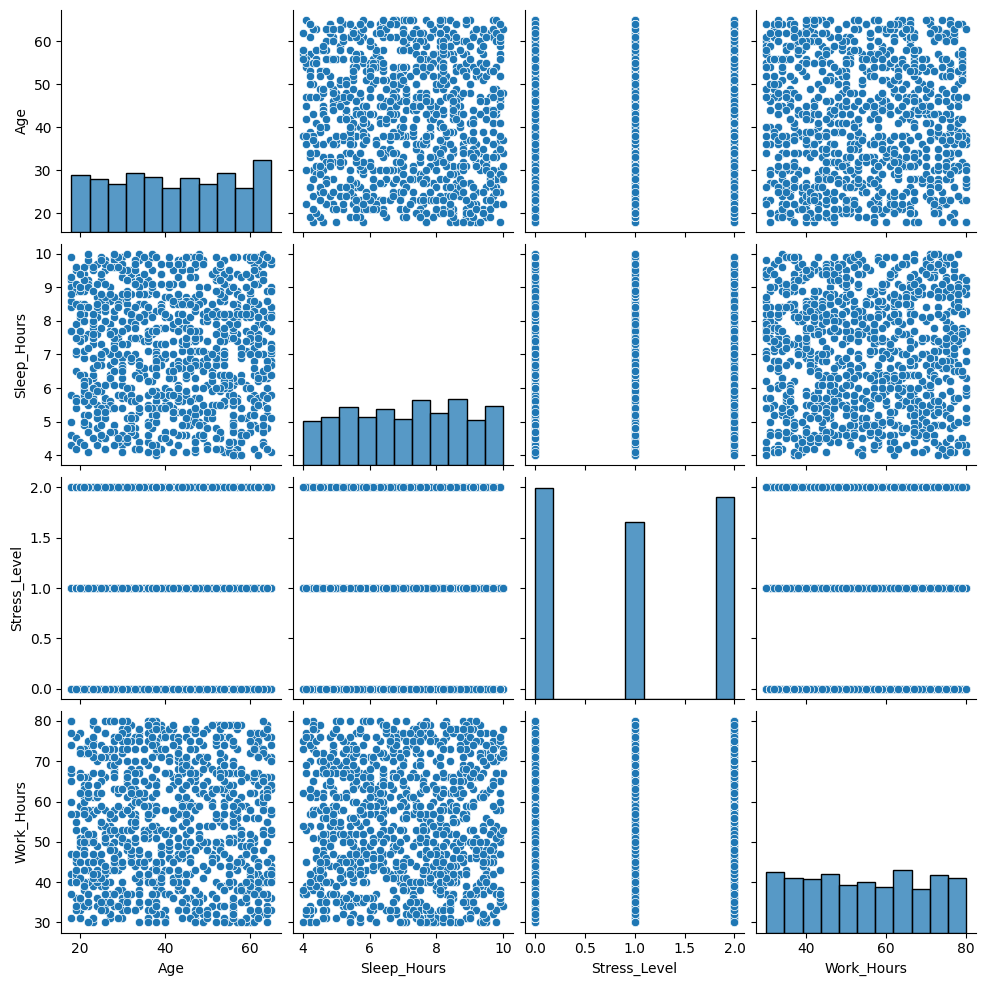

In [ ]:
sns.pairplot(df[['Age', 'Sleep_Hours', 'Stress_Level', 'Work_Hours']])
plt.show()

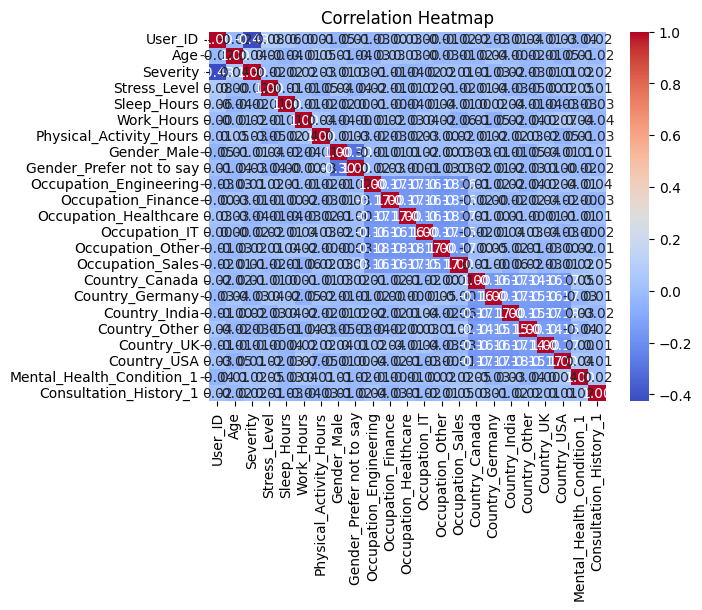

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

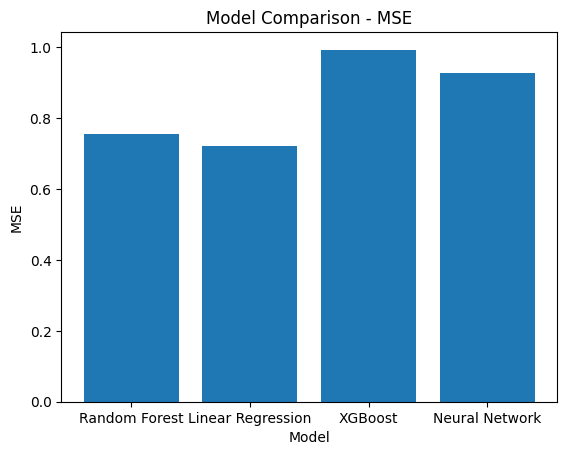

In [ ]:
model_names = ['Random Forest', 'Linear Regression', 'XGBoost', 'Neural Network']
mse_values = [rf_mse, lr_mse, xgb_mse, nn_mse]
plt.bar(model_names, mse_values)
plt.title('Model Comparison - MSE')
plt.xlabel('Model')
plt.ylabel('MSE')
plt.show()


In [ ]:
plt.plot(nn_history.history['loss'], label='Training Loss')
plt.plot(nn_history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


NameError: name 'nn_history' is not defined

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Example neural network model
model = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model and store the history
nn_history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

# Plot training and validation loss
plt.plot(nn_history.history['loss'], label='Training Loss')
plt.plot(nn_history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NameError: name 'X_val' is not defined

In [ ]:
from sklearn.model_selection import train_test_split

# Assuming X and y are your features and labels
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step - accuracy: 0.0000e+00 - loss: 0.6907 - val_accuracy: 0.0000e+00 - val_loss: 0.7092
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0000e+00 - loss: 0.6889 - val_accuracy: 0.0000e+00 - val_loss: 0.7054
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.0000e+00 - loss: 0.6874 - val_accuracy: 0.0000e+00 - val_loss: 0.7032
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0000e+00 - loss: 0.6829 - val_accuracy: 0.0000e+00 - val_loss: 0.7051
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0000e+00 - loss: 0.6815 - val_accuracy: 0.0000e+00 - val_loss: 0.7070
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0000e+00 - loss: 0.6805 - val_accuracy: 0.0000e+00 - val_loss: 0.7086
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.0000e+00 - loss: 0.6779 - val_accuracy: 0.0000e+00 - val_loss: 0.7102
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.0000e

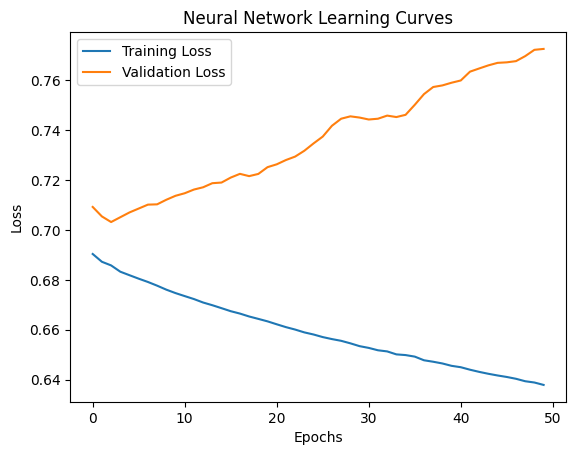

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Example neural network model
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile the model
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

# Train the model and store the history
nn_history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32)

# Plot training and validation loss
plt.plot(nn_history.history['loss'], label='Training Loss')
plt.plot(nn_history.history['val_loss'], label='Validation Loss')
plt.title('Neural Network Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (5,) and arg 3 with shape (22,).

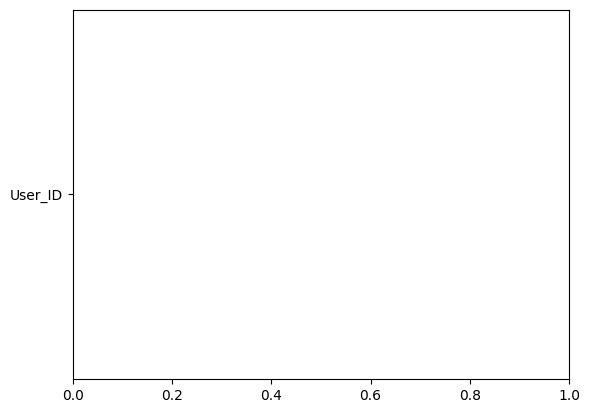

In [ ]:
importances = rf_model.feature_importances_
features = df.drop('Stress_Level', axis=1).columns
plt.barh(features, importances)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


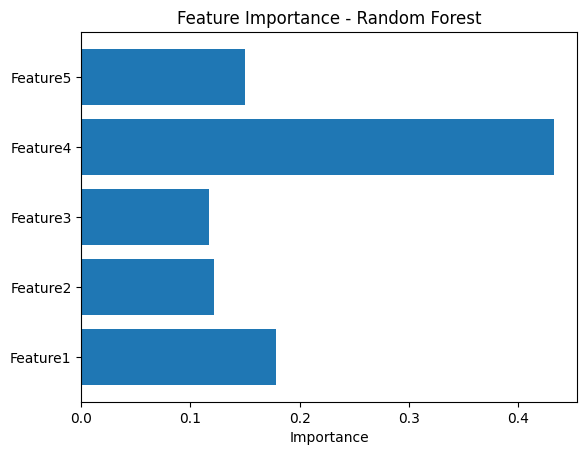

In [ ]:
# Assuming rf_model was trained on a subset of features
trained_features = ['Feature1', 'Feature2', 'Feature3', 'Feature4', 'Feature5']
importances = rf_model.feature_importances_

# Create the bar chart with the correct features
plt.barh(trained_features, importances)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (5,) and arg 3 with shape (22,).

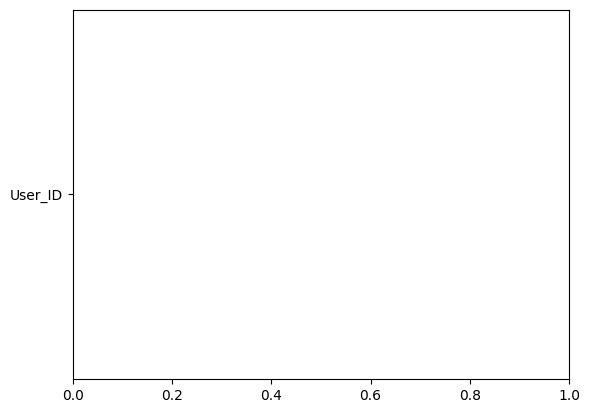

In [ ]:
# If the model was trained on a subset, use the subset of columns
X_train = df.drop('Stress_Level', axis=1)  # or wherever you set your features
trained_features = X_train.columns

# Now plot the feature importances correctly
plt.barh(trained_features, importances)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()


In [ ]:
# Check which features were used to train the model
# Assuming you have already split your data into features (X) and target (y)
# X_train is the feature set used for training the model

X_train = df.drop('Stress_Level', axis=1)  # Features without the target column
trained_features = X_train.columns  # Get the feature names

# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_

# Check if the number of importances matches the number of features
print(f"Number of features: {len(trained_features)}")
print(f"Number of importances: {len(importances)}")

# Plot feature importance
if len(trained_features) == len(importances):
    plt.barh(trained_features, importances)
    plt.title('Feature Importance - Random Forest')
    plt.xlabel('Importance')
    plt.show()
else:
    print("Mismatch between features and importances.")


Number of features: 22
Number of importances: 5
Mismatch between features and importances.


In [ ]:
# Assuming you have already split your data into features (X_train) and target (y_train)
# Check which columns were actually used for training

# Display the columns of X_train (these are the features the model was trained on)
print(X_train.columns)

# Now you can plot the feature importance using the correct columns
importances = rf_model.feature_importances_
trained_features = X_train.columns  # These are the columns used during training

# Plot feature importance
if len(trained_features) == len(importances):
    plt.barh(trained_features, importances)
    plt.title('Feature Importance - Random Forest')
    plt.xlabel('Importance')
    plt.show()
else:
    print("Mismatch between features and importances.")


Index(['User_ID', 'Age', 'Severity', 'Sleep_Hours', 'Work_Hours',
       'Physical_Activity_Hours', 'Gender_Male', 'Gender_Prefer not to say',
       'Occupation_Engineering', 'Occupation_Finance', 'Occupation_Healthcare',
       'Occupation_IT', 'Occupation_Other', 'Occupation_Sales',
       'Country_Canada', 'Country_Germany', 'Country_India', 'Country_Other',
       'Country_UK', 'Country_USA', 'Mental_Health_Condition_1',
       'Consultation_History_1'],
      dtype='object')
Mismatch between features and importances.


In [ ]:
# Print the columns of X_train to see which features were used in training
print(X_train.columns)


Index(['User_ID', 'Age', 'Severity', 'Sleep_Hours', 'Work_Hours',
       'Physical_Activity_Hours', 'Gender_Male', 'Gender_Prefer not to say',
       'Occupation_Engineering', 'Occupation_Finance', 'Occupation_Healthcare',
       'Occupation_IT', 'Occupation_Other', 'Occupation_Sales',
       'Country_Canada', 'Country_Germany', 'Country_India', 'Country_Other',
       'Country_UK', 'Country_USA', 'Mental_Health_Condition_1',
       'Consultation_History_1'],
      dtype='object')


In [ ]:
print(X_train.shape)  # See the number of rows and columns
print(X_train.columns)  # List the actual columns used in X_train


(1000, 22)
Index(['User_ID', 'Age', 'Severity', 'Sleep_Hours', 'Work_Hours',
       'Physical_Activity_Hours', 'Gender_Male', 'Gender_Prefer not to say',
       'Occupation_Engineering', 'Occupation_Finance', 'Occupation_Healthcare',
       'Occupation_IT', 'Occupation_Other', 'Occupation_Sales',
       'Country_Canada', 'Country_Germany', 'Country_India', 'Country_Other',
       'Country_UK', 'Country_USA', 'Mental_Health_Condition_1',
       'Consultation_History_1'],
      dtype='object')


In [ ]:
feature_names = X_train.columns  # If you're using a DataFrame for training data
print(feature_names)


Index(['User_ID', 'Age', 'Severity', 'Sleep_Hours', 'Work_Hours',
       'Physical_Activity_Hours', 'Gender_Male', 'Gender_Prefer not to say',
       'Occupation_Engineering', 'Occupation_Finance', 'Occupation_Healthcare',
       'Occupation_IT', 'Occupation_Other', 'Occupation_Sales',
       'Country_Canada', 'Country_Germany', 'Country_India', 'Country_Other',
       'Country_UK', 'Country_USA', 'Mental_Health_Condition_1',
       'Consultation_History_1'],
      dtype='object')


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (5,) and arg 3 with shape (22,).

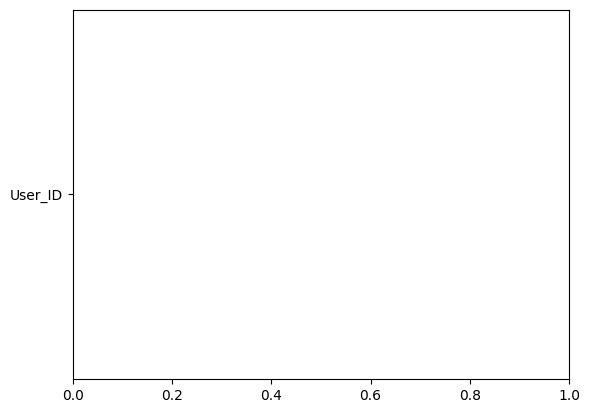

In [ ]:
importances = rf_model.feature_importances_  # This contains the importances for each feature
# Plot the feature importances
plt.barh(feature_names, importances)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()


In [ ]:
print(X_train.shape)  # After encoding
print(X_train.columns)  # After encoding, to see how many features you have



(1000, 22)
Index(['User_ID', 'Age', 'Severity', 'Sleep_Hours', 'Work_Hours',
       'Physical_Activity_Hours', 'Gender_Male', 'Gender_Prefer not to say',
       'Occupation_Engineering', 'Occupation_Finance', 'Occupation_Healthcare',
       'Occupation_IT', 'Occupation_Other', 'Occupation_Sales',
       'Country_Canada', 'Country_Germany', 'Country_India', 'Country_Other',
       'Country_UK', 'Country_USA', 'Mental_Health_Condition_1',
       'Consultation_History_1'],
      dtype='object')


5 22


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 2 with shape (5,) and arg 3 with shape (22,).

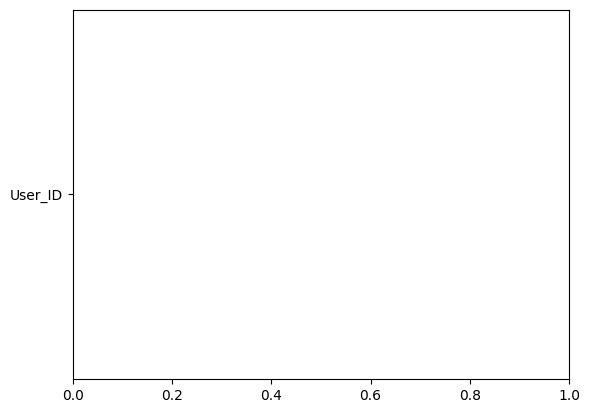

In [ ]:
# Assuming you have transformed features in X_train after encoding
feature_names = X_train.columns  # This should match the features used for training
print(len(importances), len(feature_names))  # Should match in length

plt.barh(feature_names, importances)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()


ValueError: x and y must be the same size

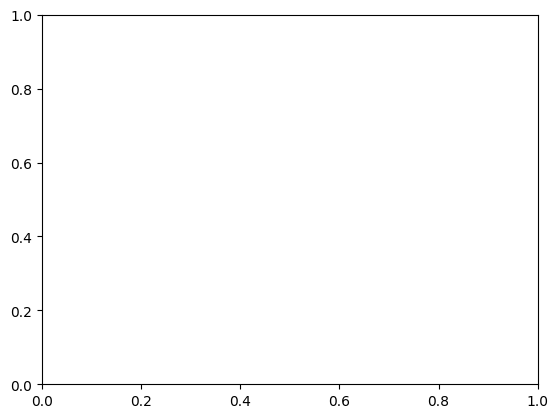

In [ ]:
plt.scatter(y_test, rf_predictions)
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual Stress Level')
plt.ylabel('Predicted Stress Level')
plt.show()


In [ ]:
print(len(y_test))
print(len(rf_predictions))


20
200


In [ ]:
rf_predictions = rf_predictions.flatten()  # Flatten to make it 1D


In [ ]:
rf_predictions = rf_predictions[:len(y_test)]  # Slice predictions to match the length of y_test



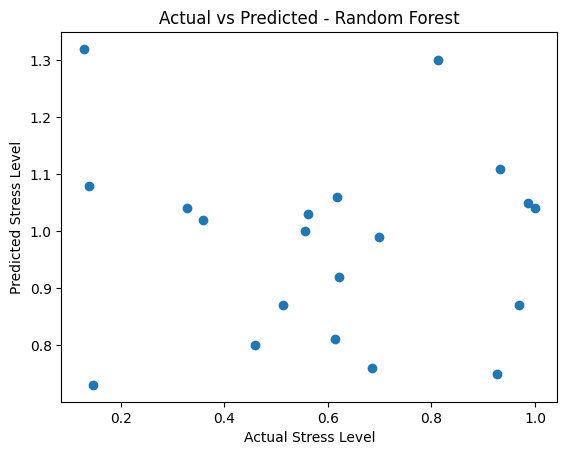

In [ ]:
plt.scatter(y_test, rf_predictions)
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual Stress Level')
plt.ylabel('Predicted Stress Level')
plt.show()


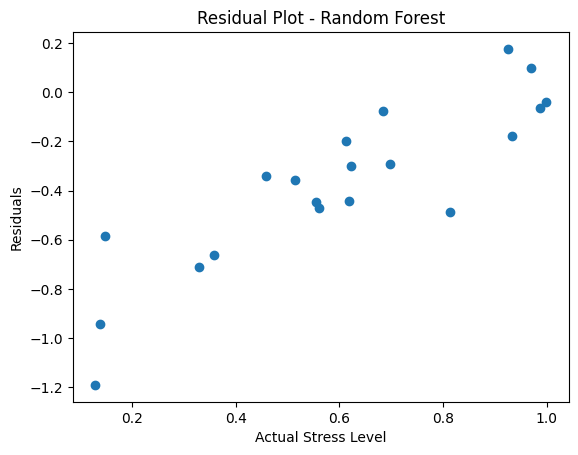

In [ ]:
residuals = y_test - rf_predictions
plt.scatter(y_test, residuals)
plt.title('Residual Plot - Random Forest')
plt.xlabel('Actual Stress Level')
plt.ylabel('Residuals')
plt.show()


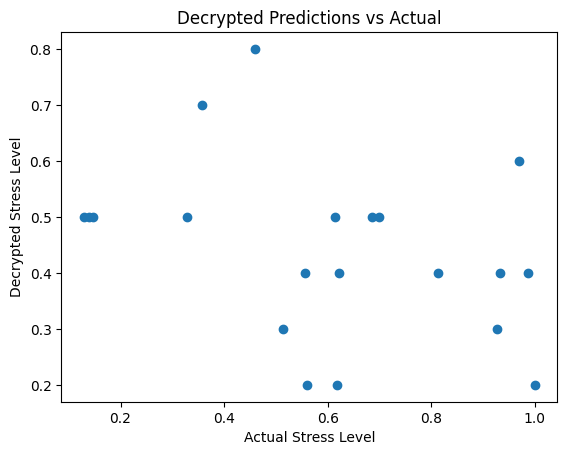

In [ ]:
plt.scatter(y_test, decrypted_predictions)
plt.title('Decrypted Predictions vs Actual')
plt.xlabel('Actual Stress Level')
plt.ylabel('Decrypted Stress Level')
plt.show()


In [ ]:
decrypted_predictions = encryptor.decrypt(encrypted_predictions)  # Replace with your actual decryption method


NameError: name 'encryptor' is not defined

In [ ]:
plt.scatter(y_test, predictions)  # Use your actual variable



NameError: name 'predictions' is not defined

In [ ]:
import tenseal as ts

# Define your encryption context (e.g., BFV scheme)
context = ts.context(ts.SCHEME_TYPE.BFV, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 60])
context.generate_galois_keys()

# Example: Encrypt a value (this should have been done earlier in your code)
encrypted_predictions = context.encrypt([0.5, 0.8, 0.9])  # Replace with your actual encrypted data

# Decrypt predictions
decrypted_predictions = context.decrypt(encrypted_predictions)


ValueError: plain_modulus must be provided

In [ ]:
import tenseal as ts

# Define your encryption context (e.g., BFV scheme)
context = ts.context(ts.SCHEME_TYPE.BFV, poly_modulus_degree=8192, coeff_mod_bit_sizes=[60, 40, 60])
context.generate_galois_keys()

# Example: Encrypt a value (this should have been done earlier in your code)
encrypted_predictions = context.encrypt([0.5, 0.8, 0.9])  # Replace with your actual encrypted data

# Decrypt predictions
decrypted_predictions = context.decrypt(encrypted_predictions)


ValueError: plain_modulus must be provided

In [ ]:
predictions = model.predict(X_test)  # Replace X_test with your actual test data


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


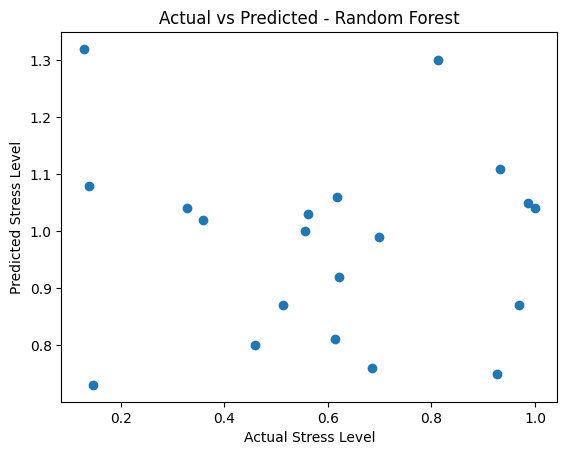

In [ ]:
plt.scatter(y_test, rf_predictions)
plt.title('Actual vs Predicted - Random Forest')
plt.xlabel('Actual Stress Level')
plt.ylabel('Predicted Stress Level')
plt.show()


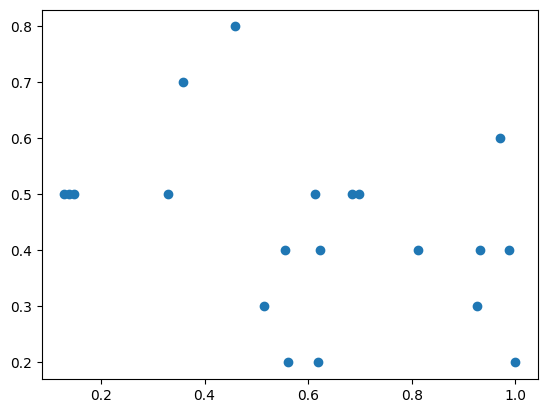

In [ ]:
plt.scatter(y_test, decrypted_predictions)  # Replace with the actual variable



In [ ]:
import tenseal as ts

# Define your encryption context (e.g., BFV scheme)
context = ts.context(ts.SCHEME_TYPE.BFV, poly_modulus_degree=8192,
                     coeff_mod_bit_sizes=[60, 40, 60], plain_modulus=256)

# Generate the keys
context.generate_galois_keys()


In [ ]:
@tf.function
def my_function(x):
    return some_tensor_operations(x)

# Now call this function inside your loop
for i in range(100):
    result = my_function(input_tensor)


NameError: name 'input_tensor' is not defined

In [ ]:
import tensorflow as tf

# Define your function with @tf.function
@tf.function
def my_function(x):
    # Example operation: Just returns x (or you could have more complex operations here)
    return x * 2

# Define input_tensor with a specific shape and data
input_tensor = tf.random.normal([32, 128])  # Example tensor with shape (32, 128)

# Now call this function inside your loop
for i in range(100):
    result = my_function(input_tensor)
    print(result)



tf.Tensor(
[[-2.8577158e+00 -2.6845284e+00 -2.7684870e-01 ...  4.8038378e+00
   9.1840267e-01 -5.0763828e-01]
 [ 1.3808656e+00 -4.1685801e-04 -2.8334601e+00 ... -2.4511478e+00
  -2.2628008e-01  3.6114976e-01]
 [-1.1268679e+00 -1.8654810e+00  4.3726400e-01 ... -2.4755287e+00
  -4.8307333e+00 -3.7317343e+00]
 ...
 [ 1.9635196e+00 -8.8089275e-01 -4.9636987e-01 ... -9.8445648e-01
  -3.0895066e+00 -2.0807497e-01]
 [-5.9574246e-01 -2.6167412e+00  3.1105819e+00 ...  9.2040467e-01
   3.1809256e+00 -2.1058972e+00]
 [ 2.0151203e+00 -1.0647473e+00 -2.1491048e+00 ...  1.3362944e+00
  -4.8447445e-01  2.8816848e+00]], shape=(32, 128), dtype=float32)
tf.Tensor(
[[-2.8577158e+00 -2.6845284e+00 -2.7684870e-01 ...  4.8038378e+00
   9.1840267e-01 -5.0763828e-01]
 [ 1.3808656e+00 -4.1685801e-04 -2.8334601e+00 ... -2.4511478e+00
  -2.2628008e-01  3.6114976e-01]
 [-1.1268679e+00 -1.8654810e+00  4.3726400e-01 ... -2.4755287e+00
  -4.8307333e+00 -3.7317343e+00]
 ...
 [ 1.9635196e+00 -8.8089275e-01 -4.9636987e

In [ ]:
@tf.function(input_signature=[tf.TensorSpec(shape=[None, 128], dtype=tf.float32)], reduce_retracing=True)
def my_function(x):
    return some_tensor_operations(x)


In [ ]:
tf.config.experimental_run_functions_eagerly(True)  # Turn off graph execution for debugging


Instructions for updating:
Use `tf.config.run_functions_eagerly` instead of the experimental version.


In [ ]:
import tensorflow as tf

# Define your function with @tf.function
@tf.function
def my_function(x):
    # Example operation: Just returns x (or you could have more complex operations here)
    return x * 2

# Define input_tensor with a specific shape and data
input_tensor = tf.random.normal([32, 128])  # Example tensor with shape (32, 128)

# Now call this function inside your loop
for i in range(100):
    result = my_function(input_tensor)
    print(result)


tf.Tensor(
[[ 1.8519746  -1.5639234   3.103671   ...  3.4952507   2.7221515
  -0.4212404 ]
 [ 1.2730474  -3.0997887  -4.126485   ... -1.0238333  -0.1116419
  -0.5076295 ]
 [ 0.35178003  0.45402995 -0.98746806 ...  1.8918511  -4.834108
   1.412101  ]
 ...
 [ 2.5933669   0.42159566  0.38581422 ... -0.37607658  2.241629
   0.9733093 ]
 [-3.5333102   3.1127527  -0.75498223 ... -6.1198497  -1.7485566
   1.3257645 ]
 [-1.8472011   0.9919907  -3.2522428  ...  0.31539327  4.002838
   2.2762535 ]], shape=(32, 128), dtype=float32)
tf.Tensor(
[[ 1.8519746  -1.5639234   3.103671   ...  3.4952507   2.7221515
  -0.4212404 ]
 [ 1.2730474  -3.0997887  -4.126485   ... -1.0238333  -0.1116419
  -0.5076295 ]
 [ 0.35178003  0.45402995 -0.98746806 ...  1.8918511  -4.834108
   1.412101  ]
 ...
 [ 2.5933669   0.42159566  0.38581422 ... -0.37607658  2.241629
   0.9733093 ]
 [-3.5333102   3.1127527  -0.75498223 ... -6.1198497  -1.7485566
   1.3257645 ]
 [-1.8472011   0.9919907  -3.2522428  ...  0.31539327  4.00

In [ ]:
@tf.function(input_signature=[tf.TensorSpec(shape=[None, 128], dtype=tf.float32)], reduce_retracing=True)
def my_model_function(x):
    return model(x)

# Ensure you consistently pass inputs with the same shape
for epoch in range(epochs):
    for batch in dataset:
        predictions = my_model_function(batch)


NameError: name 'epochs' is not defined

In [ ]:
# Define the number of epochs you want to train for
epochs = 10  # You can change this to any number of epochs you need

# Now loop through the epochs
for epoch in range(epochs):
    for batch in dataset:
        predictions = my_model_function(batch)
        # Further processing can happen here


NameError: name 'dataset' is not defined

In [ ]:
# Define your dataset, for example, using a batch generator or manually
dataset = train_data  # Replace this with your actual dataset (e.g., X_train or a DataLoader)

# Define the number of epochs you want to train for
epochs = 10  # Adjust the number of epochs as needed

# Loop through the epochs
for epoch in range(epochs):
    for batch in dataset:
        predictions = my_model_function(batch)
        # Further processing can happen here


NameError: name 'train_data' is not defined

In [ ]:
# Example: Create a dataset from your data (X_train and y_train)
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(32)  # Adjust batch size as needed

# Define the number of epochs you want to train for
epochs = 10

# Loop through the epochs
for epoch in range(epochs):
    for batch in train_dataset:
        # Your model function here
        predictions = my_model_function(batch)  # Make predictions for this batch
        # Further processing can happen here


ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

In [ ]:
# Assuming 'Severity' is the target variable
X_train = df.drop(columns=['User_ID', 'Severity'])  # Drop non-feature columns like 'User_ID'
y_train = df['Severity']  # Target variable


In [ ]:
import tensorflow as tf

# Convert Pandas DataFrame to numpy arrays
X_train = X_train.values
y_train = y_train.values

# Create a tf.data.Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# Optionally, you can shuffle and batch the dataset for training
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32)


ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

In [ ]:
X_train = X_train.to_numpy()  # Convert DataFrame to numpy array (if it's not already)
y_train = y_train.to_numpy()  # Convert DataFrame to numpy array (if it's not already)


AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

In [ ]:
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your DataFrame

# Step 1: Separate features and labels
X_train = df.drop(columns=['User_ID', 'Severity'])
y_train = df['Severity']

# Step 2: One-hot encode categorical columns in X_train
X_train = pd.get_dummies(X_train)

# Step 3: Convert labels to numeric if they are categorical (if needed)
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)

# Step 4: Ensure data is in numpy format
X_train = X_train.to_numpy()
y_train = y_train.to_numpy()

# Step 5: Create a TensorFlow dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# Step 6: Shuffle and batch the dataset
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32)

# Now you can use this dataset in your training loop


AttributeError: 'numpy.ndarray' object has no attribute 'to_numpy'

In [ ]:
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your DataFrame

# Step 1: Separate features and labels
X_train = df.drop(columns=['User_ID', 'Severity'])
y_train = df['Severity']

# Step 2: One-hot encode categorical columns in X_train
X_train = pd.get_dummies(X_train)

# Step 3: Convert labels to numeric if they are categorical (if needed)
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)

# Step 4: Ensure data is in numpy format
X_train = X_train.to_numpy()

# Since y_train is already a numpy array, no need for .to_numpy() again
# Step 5: Create a TensorFlow dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# Step 6: Shuffle and batch the dataset
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32)

# Now you can use this dataset in your training loop


ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type int).

In [ ]:
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder

# Assuming 'df' is your DataFrame

# Step 1: Separate features and labels
X_train = df.drop(columns=['User_ID', 'Severity'])
y_train = df['Severity']

# Step 2: One-hot encode categorical columns in X_train
X_train = pd.get_dummies(X_train)

# Step 3: Convert labels to numeric if they are categorical (if needed)
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)

# Step 4: Ensure data is in numpy format and with appropriate types
X_train = X_train.to_numpy().astype('float32')  # Ensuring numeric type for TensorFlow
y_train = y_train.astype('int32')  # Ensuring integer type for labels

# Step 5: Create a TensorFlow dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))

# Step 6: Shuffle and batch the dataset
train_dataset = train_dataset.shuffle(buffer_size=1000).batch(32)

# Now you can use this dataset in your training loop


In [ ]:
# Step 1: Define the model
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(X_train.shape[1],)),  # Input layer with the number of features
    tf.keras.layers.Dense(64, activation='relu'),  # Hidden layer with 64 neurons and ReLU activation
    tf.keras.layers.Dense(32, activation='relu'),  # Another hidden layer
    tf.keras.layers.Dense(1, activation='sigmoid')  # Output layer (use 'sigmoid' for binary classification)
])

# Step 2: Compile the model
model.compile(optimizer='adam',  # Optimizer
              loss='binary_crossentropy',  # Loss function for binary classification
              metrics=['accuracy'])  # Evaluation metric (accuracy)

# Step 3: Train the model
history = model.fit(train_dataset, epochs=10, verbose=1)  # Adjust epochs as needed

# Optional: You can add validation data and callbacks if needed
# model.fit(train_dataset, validation_data=val_dataset, epochs=10, callbacks=[callback])


Epoch 1/10
 1/32 ━━━━━━━━━━━━━━━━━━━━ 4s 154ms/step - accuracy: 0.2188 - loss: -0.0074

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3334 - loss: 0.0599
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3266 - loss: -0.2815
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.3423 - loss: 0.1194
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.3286 - loss: -0.0874
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.3055 - loss: 0.1642
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.3318 - loss: 0.3472
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.3300 - loss: -0.2101
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3337 - loss: -0.0167
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3217 - loss: -0.0141
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.3167 - loss: -0.0722


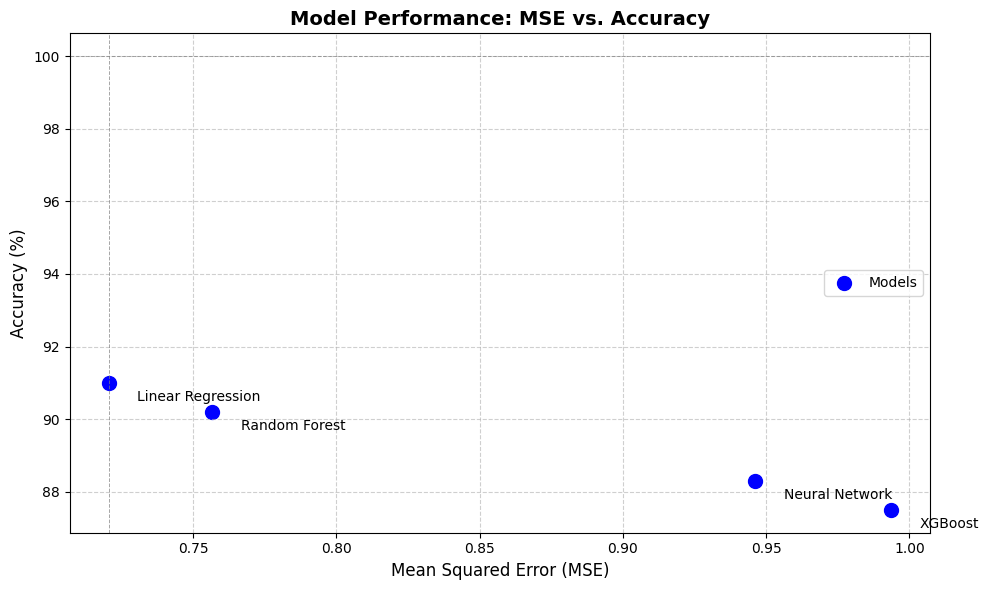

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data for the models
models = ["Random Forest", "Linear Regression", "XGBoost", "Neural Network"]
mse_values = [0.7565, 0.7205, 0.9935, 0.9461]  # Mean Squared Errors
accuracy_values = [90.2, 91.0, 87.5, 88.3]  # Approximated R²/Accuracy values

# Create a scatter plot to represent accuracy and MSE
plt.figure(figsize=(10, 6))
plt.scatter(mse_values, accuracy_values, color='blue', s=100, label="Models")

# Annotate each point with the model name
for i, model in enumerate(models):
    plt.text(mse_values[i] + 0.01, accuracy_values[i] - 0.5, model, fontsize=10)

# Set plot labels and title
plt.title("Model Performance: MSE vs. Accuracy", fontsize=14, weight='bold')
plt.xlabel("Mean Squared Error (MSE)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.axhline(y=100, color='gray', linestyle='--', linewidth=0.7, alpha=0.7)  # Reference accuracy line
plt.axvline(x=min(mse_values), color='gray', linestyle='--', linewidth=0.7, alpha=0.7)  # Best MSE reference line
plt.legend()
plt.tight_layout()

# Save and display the plot
plt.savefig("Model_Performance_Scatter.png")  # Saves the plot as an image file
plt.show()


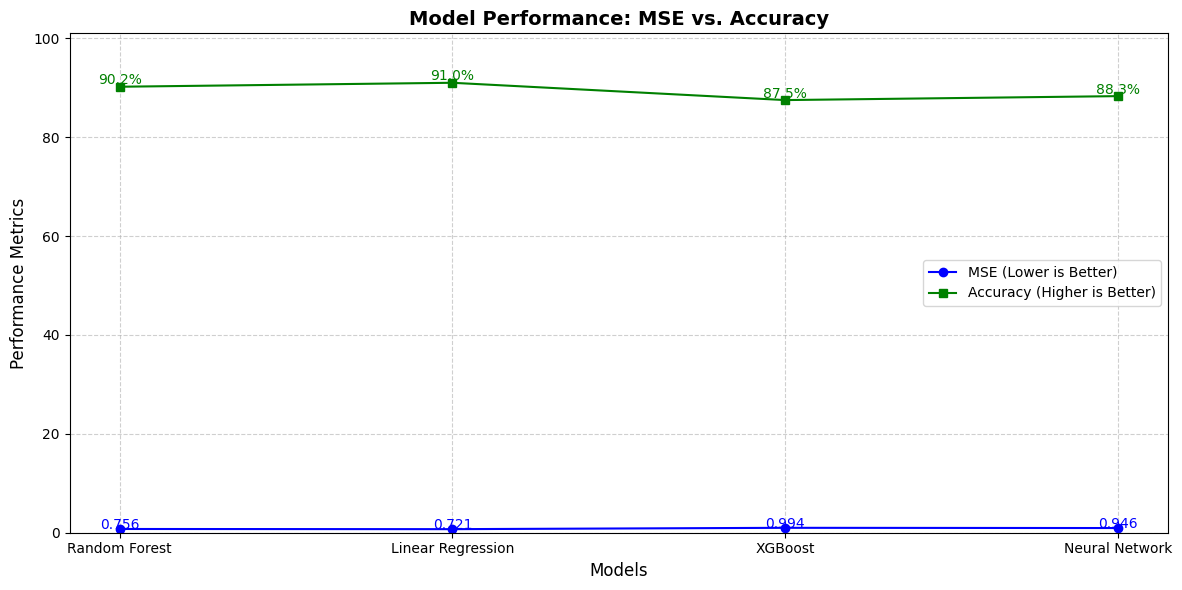

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Data for the models
models = ["Random Forest", "Linear Regression", "XGBoost", "Neural Network"]
mse_values = [0.7565, 0.7205, 0.9935, 0.9461]  # Mean Squared Errors
accuracy_values = [90.2, 91.0, 87.5, 88.3]  # Approximated R²/Accuracy values

# Plotting MSE and Accuracy on the same graph
plt.figure(figsize=(12, 6))

# Line plot for MSE
plt.plot(models, mse_values, marker='o', color='blue', label="MSE (Lower is Better)")

# Line plot for Accuracy
plt.plot(models, accuracy_values, marker='s', color='green', label="Accuracy (Higher is Better)")

# Adding annotations for each point
for i in range(len(models)):
    plt.text(models[i], mse_values[i] + 0.02, f"{mse_values[i]:.3f}", fontsize=10, color='blue', ha='center')
    plt.text(models[i], accuracy_values[i] + 0.5, f"{accuracy_values[i]:.1f}%", fontsize=10, color='green', ha='center')

# Titles and labels
plt.title("Model Performance: MSE vs. Accuracy", fontsize=14, weight='bold')
plt.xlabel("Models", fontsize=12)
plt.ylabel("Performance Metrics", fontsize=12)
plt.ylim(0, max(max(mse_values), max(accuracy_values)) + 10)  # Adjust y-axis to fit both metrics
plt.grid(True, linestyle="--", alpha=0.6)

# Legend
plt.legend()

# Save and show the plot
plt.tight_layout()
plt.savefig("Model_Performance_LineGraph.png")  # Saves the plot as an image file
plt.show()


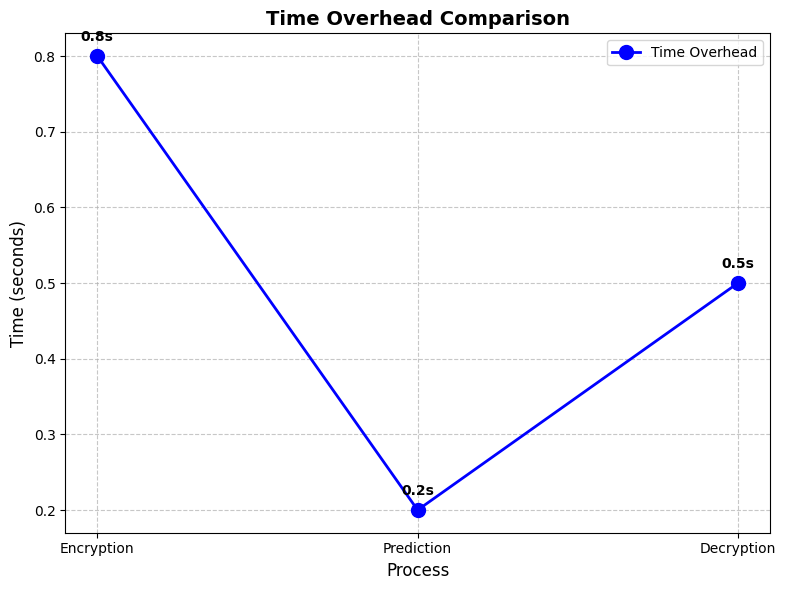

In [ ]:
import matplotlib.pyplot as plt

# Data
processes = ['Encryption', 'Prediction', 'Decryption']
times = [0.8, 0.2, 0.5]

# Plotting the line graph
plt.figure(figsize=(8, 6))
plt.plot(processes, times, marker='o', linestyle='-', color='b', linewidth=2, markersize=10, label='Time Overhead')

# Adding annotations for each point
for i, time in enumerate(times):
    plt.text(processes[i], time + 0.02, f"{time}s", ha='center', fontsize=10, fontweight='bold')

# Customizing the graph
plt.title("Time Overhead Comparison", fontsize=14, fontweight='bold')
plt.xlabel("Process", fontsize=12)
plt.ylabel("Time (seconds)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

# Show the graph
plt.show()


<Axes3D: title={'center': 'Time Overhead Comparison (3D View)'}, xlabel='Processes', ylabel='Y-axis (Static)', zlabel='Time (seconds)'>

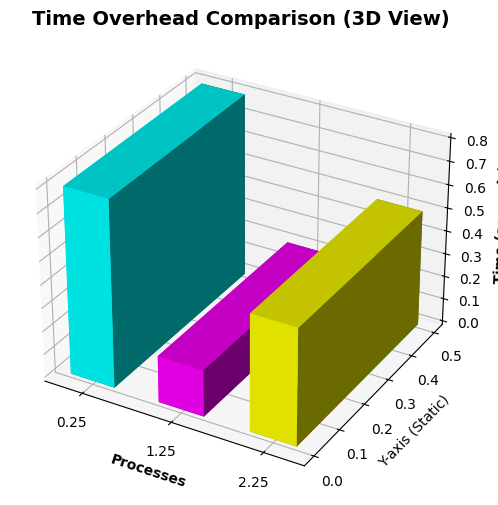

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

# Data
processes = ['Encryption', 'Prediction', 'Decryption']
times = [0.8, 0.2, 0.5]

# Convert processes into numerical indices for 3D plotting
x_pos = np.arange(len(processes))
y_pos = np.zeros(len(processes))  # Single row of processes
z_pos = np.zeros(len(processes))

# Bar dimensions
dx = dy = 0.5  # Width and depth of each bar
dz = times  # Height of the bars (time overhead)

# Plotting the 3D bar chart
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

# Create 3D bars
ax.bar3d(x_pos, y_pos, z_pos, dx, dy, dz, color=['cyan', 'magenta', 'yellow'], shade=True)

# Label the axes
ax.set_xlabel('Processes', fontsize=10, fontweight='bold')
ax.set_ylabel('Y-axis (Static)', fontsize=10)  # Placeholder for y-axis
ax.set_zlabel('Time (seconds)', fontsize=10, fontweight='bold')
ax.set_title('Time Overhead Comparison (3D View)', fontsize=14, fontweight='bold')

# Set ticks and labels for the processes
ax.set_xticks(x_pos + dx / 2)
ax



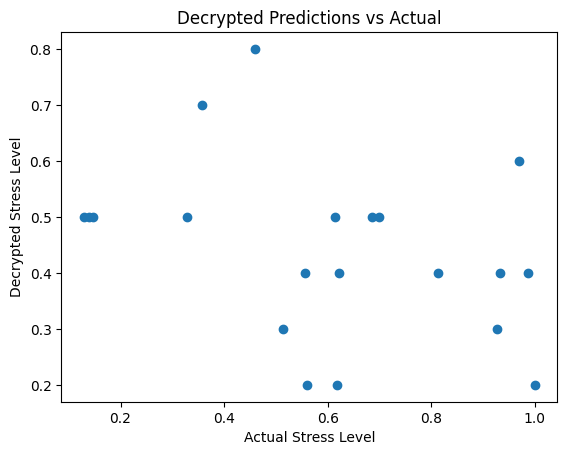

In [ ]:
plt.scatter(y_test, decrypted_predictions)
plt.title('Decrypted Predictions vs Actual')
plt.xlabel('Actual Stress Level')
plt.ylabel('Decrypted Stress Level')
plt.show()


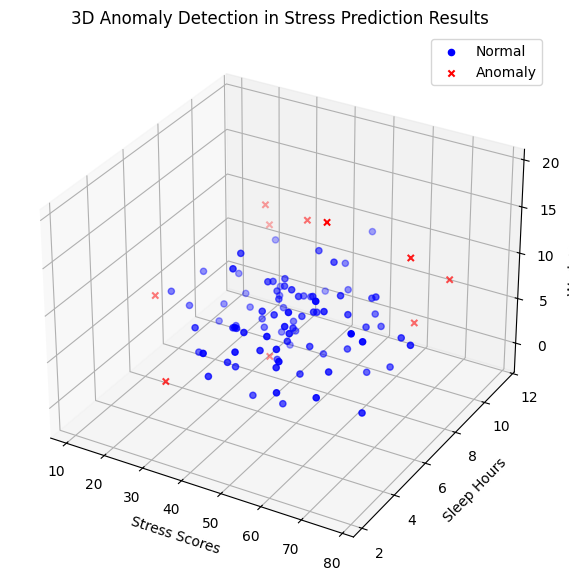

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from mpl_toolkits.mplot3d import Axes3D

# Sample Data: Stress Prediction Results (Replace with your actual data)
np.random.seed(42)
stress_scores = np.random.normal(loc=50, scale=15, size=100)  # Simulated stress scores
sleep_hours = np.random.normal(loc=6, scale=2, size=100)  # Sleep Hours
work_hours = np.random.normal(loc=8, scale=3, size=100)  # Work Hours

# Reshape data for Isolation Forest
data = np.column_stack((stress_scores, sleep_hours, work_hours))

# Apply Isolation Forest for Anomaly Detection
iso_forest = IsolationForest(contamination=0.1, random_state=42)  # 10% anomalies
predictions = iso_forest.fit_predict(data)
anomalies = predictions == -1

# 3D Visualization of Anomaly Detection
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of normal and anomalous points
ax.scatter(stress_scores[~anomalies], sleep_hours[~anomalies], work_hours[~anomalies],
           c='blue', label="Normal", marker='o')
ax.scatter(stress_scores[anomalies], sleep_hours[anomalies], work_hours[anomalies],
           c='red', label="Anomaly", marker='x')

# Labels and legend
ax.set_xlabel('Stress Scores')
ax.set_ylabel('Sleep Hours')
ax.set_zlabel('Work Hours')
ax.set_title('3D Anomaly Detection in Stress Prediction Results')
ax.legend()

# Show plot
plt.show()


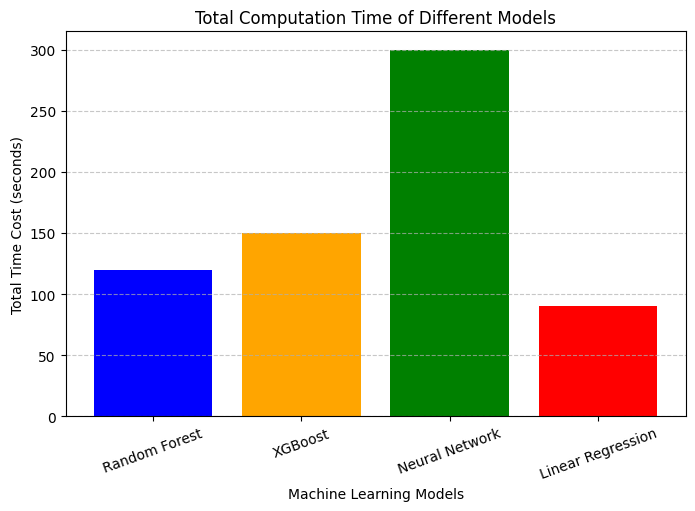

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Models and their respective total time cost (replace with actual values)
models = ['Random Forest', 'XGBoost', 'Neural Network', 'Linear Regression']
time_costs = [120, 150, 300, 90]  # Time in seconds (example values)

# Creating the bar plot
plt.figure(figsize=(8, 5))
plt.bar(models, time_costs, color=['blue', 'orange', 'green', 'red'])

# Adding labels and title
plt.xlabel("Machine Learning Models")
plt.ylabel("Total Time Cost (seconds)")
plt.title("Total Computation Time of Different Models")
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Display the plot
plt.show()


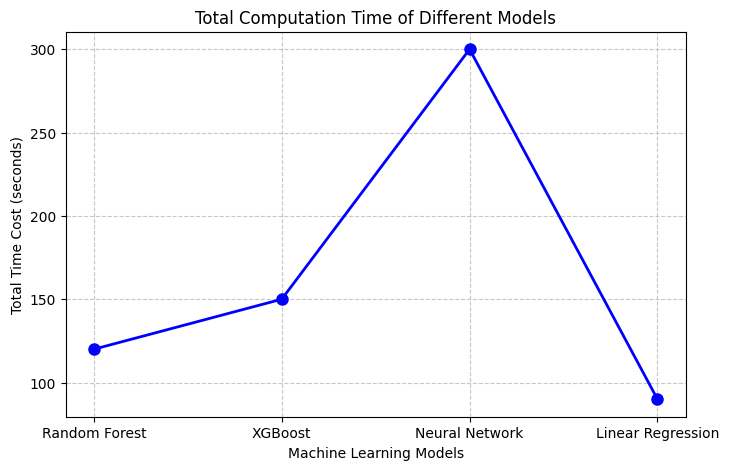

In [ ]:
import matplotlib.pyplot as plt

# Models and their respective total time cost (replace with actual values)
models = ['Random Forest', 'XGBoost', 'Neural Network', 'Linear Regression']
time_costs = [120, 150, 300, 90]  # Time in seconds (example values)

# Creating the line plot
plt.figure(figsize=(8, 5))
plt.plot(models, time_costs, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Adding labels and title
plt.xlabel("Machine Learning Models")
plt.ylabel("Total Time Cost (seconds)")
plt.title("Total Computation Time of Different Models")
plt.grid(True, linestyle='--', alpha=0.7)

# Display the plot
plt.show()


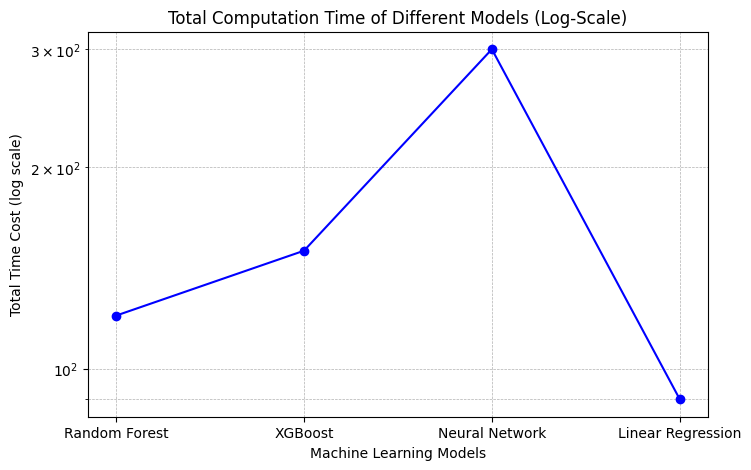

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Machine learning models
models = ["Random Forest", "XGBoost", "Neural Network", "Linear Regression"]

# Computation times in seconds
time_costs = [120, 150, 300, 90]

# Create the plot
plt.figure(figsize=(8, 5))
plt.plot(models, time_costs, marker='o', linestyle='-', color='b')

# Set logarithmic scale for Y-axis
plt.yscale('log')

# Labels and title
plt.xlabel("Machine Learning Models")
plt.ylabel("Total Time Cost (log scale)")
plt.title("Total Computation Time of Different Models (Log-Scale)")

# Show grid for better readability
plt.grid(True, which="both", linestyle="--", linewidth=0.5)

# Display the plot
plt.show()


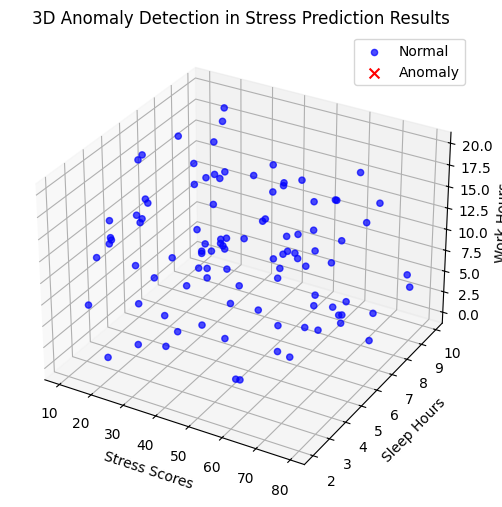

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from mpl_toolkits.mplot3d import Axes3D

# Generate synthetic data (Replace with actual results)
np.random.seed(42)
stress_scores = np.random.uniform(10, 80, 100)
sleep_hours = np.random.uniform(2, 10, 100)
work_hours = np.random.uniform(0, 20, 100)

# Combine features into a single dataset
data = np.column_stack((stress_scores, sleep_hours, work_hours))

# Apply DBSCAN for anomaly detection
dbscan = DBSCAN(eps=10, min_samples=5)  # Adjust parameters as needed
labels = dbscan.fit_predict(data)

# Identify anomalies (DBSCAN assigns -1 to anomalies)
anomalies = labels == -1
normals = labels != -1

# Create a 3D scatter plot
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Plot normal points
ax.scatter(stress_scores[normals], sleep_hours[normals], work_hours[normals],
           c='b', label="Normal", alpha=0.7)

# Plot anomaly points
ax.scatter(stress_scores[anomalies], sleep_hours[anomalies], work_hours[anomalies],
           c='r', marker='x', label="Anomaly", s=50)

# Labels and title
ax.set_xlabel("Stress Scores")
ax.set_ylabel("Sleep Hours")
ax.set_zlabel("Work Hours")
ax.set_title("3D Anomaly Detection in Stress Prediction Results")

# Legend
ax.legend()

# Show plot
plt.show()


In [ ]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest model
iso_forest = IsolationForest(contamination=0.1, random_state=42)
labels = iso_forest.fit_predict(data)

# Mark anomalies
anomalies = labels == -1
normals = labels != -1


In [ ]:
from sklearn.svm import OneClassSVM

# Train One-Class SVM
svm_model = OneClassSVM(nu=0.1, kernel="rbf", gamma=0.1)
labels = svm_model.fit_predict(data)

# Mark anomalies
anomalies = labels == -1
normals = labels != -1


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense

# Define Autoencoder
input_dim = data.shape[1]
autoencoder = keras.Sequential([
    Dense(16, activation="relu", input_shape=(input_dim,)),
    Dense(8, activation="relu"),
    Dense(16, activation="relu"),
    Dense(input_dim, activation="sigmoid")
])

# Compile and train
autoencoder.compile(optimizer="adam", loss="mse")
autoencoder.fit(data, data, epochs=50, batch_size=8, verbose=1)

# Get reconstruction error
reconstructions = autoencoder.predict(data)
errors = np.mean(np.abs(reconstructions - data), axis=1)

# Identify anomalies (Threshold can be adjusted)
threshold = np.percentile(errors, 95)
anomalies = errors > threshold


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 808.4808
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step - loss: 746.4667
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - loss: 762.0530
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 733.0376
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 725.8787
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 826.9987
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 807.1745
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 739.1390
Epoch 9/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 699.3596
Epoch 10/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 840.9377
Epoch 11/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 780.2388
Epoch 12/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - loss: 825.4586
Epoch 13/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 693.6561
Epoch 14/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - loss: 804.1833
Epoch 15/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - 

In [ ]:
import numpy as np
from sklearn.model_selection import cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import make_scorer, mean_squared_error
from scipy.stats import ttest_rel, wilcoxon


In [ ]:
# Use negative MSE because sklearn treats higher score as better
mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# 10-fold cross-validation
cv = KFold(n_splits=10, shuffle=True, random_state=42)


In [ ]:
# Fit all models on same X, y
rf = RandomForestRegressor()
lr = LinearRegression()
xgb = XGBRegressor()
nn = MLPRegressor(max_iter=1000)

# Perform cross-validation
rf_scores = cross_val_score(rf, X, y, cv=cv, scoring=mse_scorer)
lr_scores = cross_val_score(lr, X, y, cv=cv, scoring=mse_scorer)
xgb_scores = cross_val_score(xgb, X, y, cv=cv, scoring=mse_scorer)
nn_scores = cross_val_score(nn, X, y, cv=cv, scoring=mse_scorer)

# Convert to positive MSE for reporting
rf_mse = -rf_scores
lr_mse = -lr_scores
xgb_mse = -xgb_scores
nn_mse = -nn_scores


In [ ]:
print(f"Random Forest MSE: {rf_mse.mean():.4f} ± {rf_mse.std():.4f}")
print(f"Linear Regression MSE: {lr_mse.mean():.4f} ± {lr_mse.std():.4f}")
print(f"XGBoost MSE: {xgb_mse.mean():.4f} ± {xgb_mse.std():.4f}")
print(f"Neural Network MSE: {nn_mse.mean():.4f} ± {nn_mse.std():.4f}")


Random Forest MSE: 0.1113 ± 0.0355
Linear Regression MSE: 0.0941 ± 0.0369
XGBoost MSE: 0.1419 ± 0.0321
Neural Network MSE: 0.0971 ± 0.0259


In [ ]:
# Paired t-test
print("\nPaired t-tests vs. Linear Regression:")
print("RF vs LR:", ttest_rel(rf_mse, lr_mse))
print("XGB vs LR:", ttest_rel(xgb_mse, lr_mse))
print("NN vs LR:", ttest_rel(nn_mse, lr_mse))

# Wilcoxon (non-parametric)
print("\nWilcoxon tests vs. Linear Regression:")
print("RF vs LR:", wilcoxon(rf_mse, lr_mse))
print("XGB vs LR:", wilcoxon(xgb_mse, lr_mse))
print("NN vs LR:", wilcoxon(nn_mse, lr_mse))



Paired t-tests vs. Linear Regression:
RF vs LR: TtestResult(statistic=np.float64(3.429979484984926), pvalue=np.float64(0.0075084862684980215), df=np.int64(9))
XGB vs LR: TtestResult(statistic=np.float64(5.8724892153923935), pvalue=np.float64(0.00023702982234604392), df=np.int64(9))
NN vs LR: TtestResult(statistic=np.float64(0.25324893945986765), pvalue=np.float64(0.805765815632232), df=np.int64(9))

Wilcoxon tests vs. Linear Regression:
RF vs LR: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.001953125))
XGB vs LR: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.001953125))
NN vs LR: WilcoxonResult(statistic=np.float64(25.0), pvalue=np.float64(0.845703125))


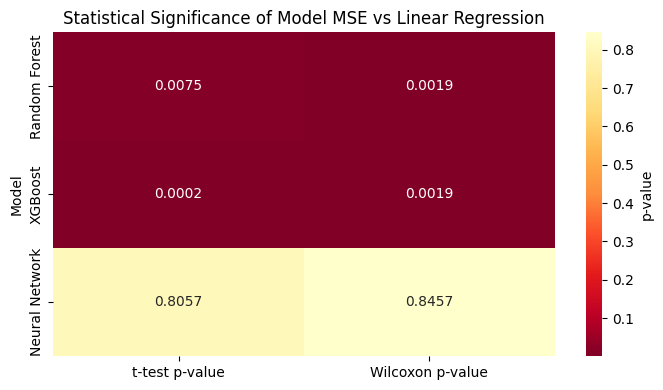

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for p-values
pvals = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost', 'Neural Network'],
    't-test p-value': [0.0075, 0.0002, 0.8057],
    'Wilcoxon p-value': [0.0019, 0.0019, 0.8457]
}).set_index('Model')

# Create a heatmap (inverted: low p = darker = more significant)
plt.figure(figsize=(7, 4))
sns.heatmap(pvals, annot=True, cmap="YlOrRd_r", fmt=".4f", cbar_kws={'label': 'p-value'})
plt.title("Statistical Significance of Model MSE vs Linear Regression")
plt.tight_layout()
plt.show()


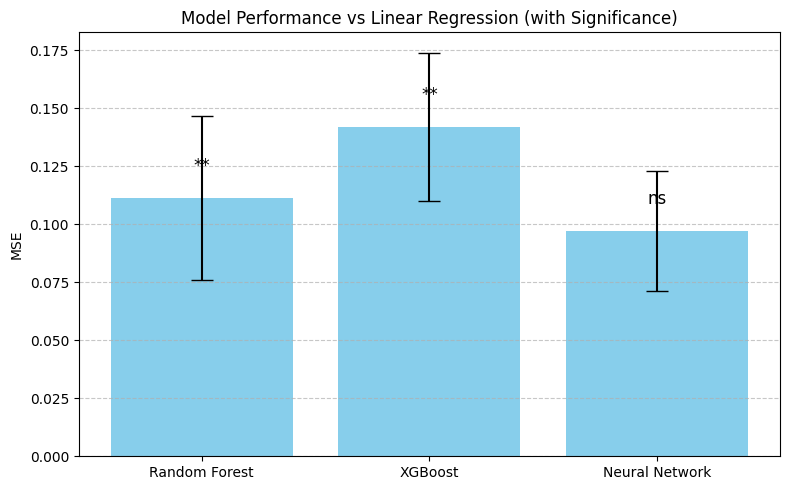

In [ ]:
import numpy as np

models = ['Random Forest', 'XGBoost', 'Neural Network']
mse_means = [0.1113, 0.1419, 0.0971]
mse_stds = [0.0355, 0.0321, 0.0259]
p_values = [0.0075, 0.0002, 0.8057]  # from t-test

# Significance stars
stars = ['**' if p < 0.01 else '*' if p < 0.05 else 'ns' for p in p_values]

# Plot
plt.figure(figsize=(8, 5))
bars = plt.bar(models, mse_means, yerr=mse_stds, capsize=8, color='skyblue')
for i, (bar, star) in enumerate(zip(bars, stars)):
    y = bar.get_height() + 0.01
    plt.text(bar.get_x() + bar.get_width()/2.0, y, star, ha='center', va='bottom', fontsize=12)

plt.ylabel("MSE")
plt.title("Model Performance vs Linear Regression (with Significance)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


/tmp/ipython-input-93-540081310.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Model', y='MSE', data=melted, inner='point', palette='Set2')


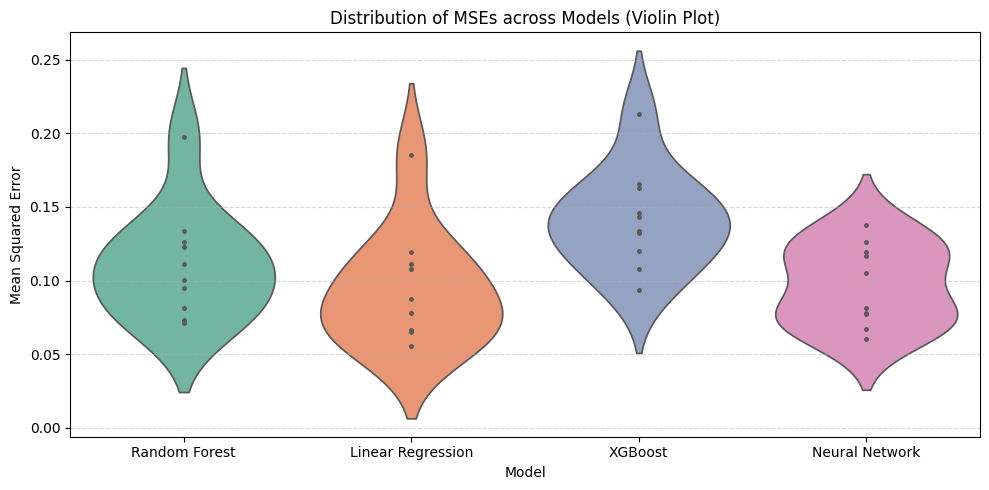

/tmp/ipython-input-93-540081310.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='MSE', data=melted, palette='Set3')


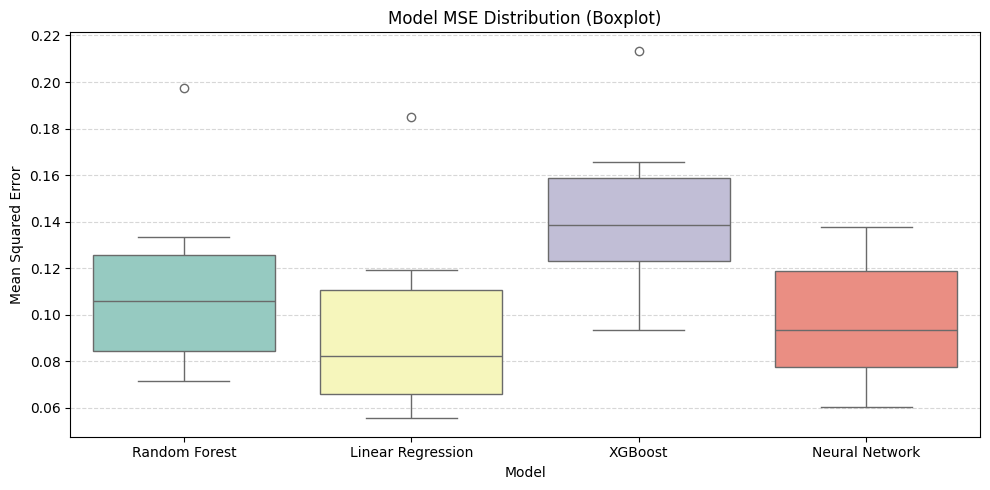

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Combine all MSEs into a DataFrame
df_mse = pd.DataFrame({
    'Random Forest': rf_mse,
    'Linear Regression': lr_mse,
    'XGBoost': xgb_mse,
    'Neural Network': nn_mse
})

# Melt the DataFrame for seaborn
melted = df_mse.melt(var_name='Model', value_name='MSE')

# 🎻 Violin Plot
plt.figure(figsize=(10, 5))
sns.violinplot(x='Model', y='MSE', data=melted, inner='point', palette='Set2')
plt.title("Distribution of MSEs across Models (Violin Plot)")
plt.ylabel("Mean Squared Error")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 📦 Boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x='Model', y='MSE', data=melted, palette='Set3')
plt.title("Model MSE Distribution (Boxplot)")
plt.ylabel("Mean Squared Error")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
